# Phase 06A - Unified Proposed and Baseline Models Comparison Dashboard

This notebook synthesizes completed BTUMQA-225K model outputs into one reviewer-facing result sheet. It does not train models, run inference, or overwrite earlier Phase 04/05 results.

Included model groups:

- Proposed clean uncertainty-guided regional models from Phase 05B and 05C.
- Supervised frozen biomedical VLM feature baseline from Phase 05D_A4.
- Supervised frozen CNN feature baselines from Phase 05D_B1.
- Supervised frozen vision Transformer feature baselines from Phase 05D_C1.
- Frozen native biomedical VLM inference baseline from Phase 05E and A3.


## Paper-Safe Policy

- Proposed Framework: AUGR-VQA = Adp-PRUGTM-Hybrid + Q-CUR
- Proposed-model evaluation and calibration is reused from Phase 05B.
- Proposed-model statistical robustness is reused from Phase 05C.
- Baseline reliability and optional bootstrap summaries are computed only from completed summary and prediction artifacts.
- CNN and ViT/Swin baselines are not described as VLMs.
- Q-CUR is not claimed to be best on every calibration metric.
- Metadata-controlled training is not described as bias-free.


## Environment Imports and Styling


In [ ]:
import json
import math
import os
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score

try:
    import torch
except Exception:
    torch = None


try:
    from IPython.display import display
except Exception:
    display = print


sns.set_theme(style="whitegrid", context="paper")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

PHASE05B_BACKBONE_PALETTE = {
    "No-UGTM": "#c98936",
    "No-UGTM + Q-CUR": "#c98936",
    "UGTM-QGCA": "#2f6f9f",
    "UGTM-QGCA + Q-CUR": "#2f6f9f",
    "PRUGTM-Hybrid": "#2a9d8f",
    "PRUGTM-Hybrid + Q-CUR": "#2a9d8f",
    "QAdp-PRUGTM-Hybrid": "#7659a6",
    "QAdp-PRUGTM-Hybrid + Q-CUR": "#7659a6",
}
PHASE05B_METHOD_PALETTE = {"Raw": "#b85c5c", "Posthoc": "#d39b2f", "Q-CUR": "#247a69"}
MODEL_FAMILY_PALETTE = {
    "Proposed uncertainty-guided regional model": "#7659a6",
    "Supervised frozen biomedical VLM feature baseline": "#247a69",
    "Supervised frozen CNN feature baseline": "#2f6f9f",
    "Supervised frozen vision Transformer feature baseline": "#c98936",
    "Frozen native biomedical VLM inference baseline": "#6b7280",
}

RANDOM_SEED = 20260607
RNG = np.random.default_rng(RANDOM_SEED)
DEFAULT_BOOTSTRAP_REPLICATES = 2000
BOOTSTRAP_BATCH_SIZE = 128
BOOTSTRAP_BACKEND = "auto"  # "auto", "cuda", or "cpu"
MIN_BOOTSTRAP_ROWS = 100

print("Phase 06A imports ready.")


Phase 06A imports ready.


## Project Paths and Output Registry


In [ ]:
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    drive = None
    IN_COLAB = False


if IN_COLAB:
    drive.mount("/content/drive")
    # Updated project path to point to the new drive structure
    PROJECT_DIR = Path("/content/drive/MyDrive/AUGR-VQA")
else:
    PROJECT_DIR = Path.cwd()

# Corrected paths: phase_6/p6a_models_unified_comparison_results_showcase/btumqa_225k_clean_metadata_models_unified_comparison_results_showcase
PHASE06A_DIR = PROJECT_DIR / "phase_6" / "p6a_models_unified_comparison_results_showcase" / "btumqa_225k_clean_metadata_models_unified_comparison_results_showcase"
TABLES_DIR = PHASE06A_DIR / "tables"
FIGURES_DIR = PHASE06A_DIR / "figures"
REPORTS_DIR = PHASE06A_DIR / "reports"
DONE_DIR = PHASE06A_DIR / "done"

for path in [PHASE06A_DIR, TABLES_DIR, FIGURES_DIR, REPORTS_DIR, DONE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Corrected input paths pointing to phase_5/
PHASE5B_DIR = PROJECT_DIR / "phase_5" / "p5b_final_evaluation_ablation_calibration" / "btumqa_225k_clean_metadata_four_seeds_final_comparison"
PHASE5C_DIR = PROJECT_DIR / "phase_5" / "p5c_statistical_confidence_slice_robustness" / "btumqa_225k_clean_metadata_four_seeds_statistical_robustness_boot2000"
PHASE5D_BASE_DIR = PROJECT_DIR / "phase_5" / "p5d_modern_baseline_comparison_models"
PHASE5E_DIR = PROJECT_DIR / "phase_5" / "p5e_modern_vlm_baseline_comparison" / "btumqa_225k_vlms_global23_prompt_ensemble_comparison"

def first_existing_path(*paths: Path) -> Path:
    for path in paths:
        if path.exists():
            return path
    return paths[0]


PHASE5D_STRUCTURED_BASE_DIR = PROJECT_DIR / "phase_5" / "p5d_modern_baseline_comparison_models"
PHASE5E_DIR = PROJECT_DIR / "phase_5" / "p5e_modern_vlm_baseline_comparison" / "btumqa_225k_vlms_global23_prompt_ensemble_comparison"

A4_RUN_DIR = PHASE5D_STRUCTURED_BASE_DIR / "vlm_comparison" / "phase05d_a4_biomedclip_frozen_feature_supervised_baseline"
B1_RUN_DIR = PHASE5D_STRUCTURED_BASE_DIR / "cnn_model_comparison" / "phase05d_b1_cnn_frozen_feature_supervised_baselines"
C1_RUN_DIR = PHASE5D_STRUCTURED_BASE_DIR / "attention_model_comparison" / "phase05d_c1_attention_frozen_feature_supervised_baselines"


Mounted at /content/drive
Resolved A4 run dir: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5d_modern_baseline_comparison_models/vlm_comparison/phase05d_a4_biomedclip_frozen_feature_supervised_baseline
Resolved B1 run dir: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5d_modern_baseline_comparison_models/cnn_model_comparison/phase05d_b1_cnn_frozen_feature_supervised_baselines
Resolved C1 run dir: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5d_modern_baseline_comparison_models/attention_model_comparison/phase05d_c1_attention_frozen_feature_supervised_baselines
Phase 05E dir: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5e_modern_vlm_baseline_comparison/btumqa_225k_vlms_global23_prompt_ensemble_comparison
Project dir: /content/drive/MyDrive

## Notebook Helper Functions


In [ ]:
def now_string() -> str:
    return time.strftime("%Y-%m-%d %H:%M:%S")


def read_csv_optional(path: Path, name: str) -> pd.DataFrame:
    if path.exists():
        df = pd.read_csv(path)
        print(f"Loaded {name}: {path} ({len(df):,} rows)")
        return df
    print(f"Missing optional artifact for {name}: {path}")
    return pd.DataFrame()


def write_json(path: Path, payload: dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(payload, indent=2), encoding="utf-8")


def save_dataframe(df: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    print(f"Saved {path} ({len(df):,} rows)")


def first_existing_column(row: pd.Series, candidates: list[str], default=np.nan):
    for col in candidates:
        if col in row.index and pd.notna(row[col]):
            return row[col]
    return default


PROPOSED_PHASE5B_BACKBONE_KEY = {
    "no_ugtm": "no_ugtm_clean",
    "ugtm": "ugtm_qgca_clean",
    "prugtm": "prugtm_hybrid_clean",
    "qadp": "qadp_prugtm_hybrid_clean",
}


def mean_from_prediction_files(paths: list[Path], confidence_columns: list[str]) -> float:
    means = []
    for path in paths:
        if not path.exists():
            continue
        try:
            df = pd.read_csv(path)
        except Exception as exc:
            print(f"Could not read confidence file {path}: {exc!r}")
            continue
        for col in confidence_columns:
            if col in df.columns:
                values = pd.to_numeric(df[col], errors="coerce").dropna()
                if len(values):
                    means.append(float(values.mean()))
                break
    return float(np.mean(means)) if means else np.nan


def proposed_qcur_mean_confidence(proposed_key: str) -> float:
    backbone_key = PROPOSED_PHASE5B_BACKBONE_KEY.get(proposed_key)
    if not backbone_key:
        return np.nan
    prediction_dir = PHASE5B_DIR / "predictions" / backbone_key
    paths = sorted(prediction_dir.glob("*/test_calibrated_predictions.csv")) if prediction_dir.exists() else []
    return mean_from_prediction_files(paths, ["qcur_confidence", "calibrated_confidence", "confidence"])


def a3_native_mean_confidence() -> float:
    candidate_paths = [
        PROJECT_DIR / "phase_5" / "p5d_modern_baseline_comparison_models" / "vlm_comparison" / "phase05d_a3_biomedclip_global23_dual_view_naturalized" / "predictions" / "test_predictions.csv",
        PROJECT_DIR / "phase_5d_vlm_global23_prompt_ensemble" / "phase05d_a3_biomedclip_global23_dual_view_naturalized" / "predictions" / "test_predictions.csv",
        PROJECT_DIR / "phase_5d_modern_vlm_baseline_comparison" / "phase05d_a3_biomedclip_global23_dual_view_naturalized" / "predictions" / "test_predictions.csv",
        PROJECT_DIR / "phase_5d_modern_baseline_comparison_models" / "vlm_comparison" / "phase05d_a3_biomedclip_global23_dual_view_naturalized" / "predictions" / "test_predictions.csv",
        PROJECT_DIR / "phase_5d_modern_baseline_comparison_models" / "phase05d_a3_biomedclip_global23_dual_view_naturalized" / "predictions" / "test_predictions.csv",
    ]
    return mean_from_prediction_files(candidate_paths, ["confidence", "native_confidence", "best_probability"])


def with_filled_mean_confidence(row: pd.Series | dict, fallback_value: float) -> pd.Series:
    src = pd.Series(row).copy()
    current = first_existing_column(src, metric_column_candidates("mean_confidence"), np.nan) if "metric_column_candidates" in globals() else np.nan
    if pd.isna(current) and pd.notna(fallback_value):
        src["mean_confidence"] = float(fallback_value)
    return src


def metric_column_candidates(base: str) -> list[str]:
    return [
        base,
        f"{base}__mean",
        f"{base}_mean",
        f"test_{base}_mean",
        f"test_{base}",
        f"{base}__median",
        f"{base}_median",
    ]


def normalize_metric_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    rename_map = {}
    for base in ["accuracy", "macro_f1", "weighted_f1", "ece", "brier", "nll", "aurc", "mean_confidence"]:
        if base not in out.columns:
            for candidate in metric_column_candidates(base):
                if candidate != base and candidate in out.columns:
                    rename_map[candidate] = base
                    break
    if rename_map:
        out = out.rename(columns=rename_map)
    return out


def infer_variant_type(model_label: str, model_key: str = "") -> str:
    text = f"{model_label} {model_key}".lower()
    if "image-only" in text or "image_only" in text:
        return "image-only control"
    if "question+image" in text or "question_image" in text:
        return "question+image"
    if "q-cur" in text:
        return "q-cur calibrated"
    return "model"


def clean_model_label(value: str) -> str:
    text = str(value)
    text = text.replace(" Clean", "")
    text = text.replace("Clean ", "")
    text = text.replace("Dual-View ", "")
    # Keep pretraining information in protocol/metadata, not in visible paper labels.
    text = text.replace(" ImageNet", "")
    text = text.replace("  ", " ").strip()
    return text


def make_row(
    *,
    tier: str,
    model_family: str,
    model_label: str,
    experiment_key: str,
    internal_code: str,
    protocol: str,
    inputs: str,
    calibration_source: str,
    seed_protocol: str,
    row: pd.Series | dict,
    variant_type: str | None = None,
    changed_component: str = "",
    headline_eligible: bool = True,
) -> dict:
    src = pd.Series(row)
    return {
        "tier": tier,
        "model_family": model_family,
        "model_label": clean_model_label(model_label),
        "variant_type": variant_type or infer_variant_type(model_label, experiment_key),
        "removed_or_changed_component": changed_component,
        "experiment_key": experiment_key,
        "internal_code": internal_code,
        "protocol": protocol,
        "inputs": inputs,
        "seed_protocol": seed_protocol,
        "calibration_source": calibration_source,
        "accuracy": first_existing_column(src, metric_column_candidates("accuracy")),
        "macro_f1": first_existing_column(src, metric_column_candidates("macro_f1")),
        "weighted_f1": first_existing_column(src, metric_column_candidates("weighted_f1")),
        "ece": first_existing_column(src, metric_column_candidates("ece")),
        "brier": first_existing_column(src, metric_column_candidates("brier")),
        "nll": first_existing_column(src, metric_column_candidates("nll")),
        "aurc": first_existing_column(src, metric_column_candidates("aurc")),
        "mean_confidence": first_existing_column(src, metric_column_candidates("mean_confidence")),
        "num_seeds": first_existing_column(src, ["num_seeds", "n_seeds", "num_runs", "seed_count"], np.nan),
        "headline_eligible": bool(headline_eligible),
    }


def display_or_empty(df: pd.DataFrame, name: str, n: int = 10) -> None:
    print(f"{name}: {len(df):,} rows")
    if not df.empty:
        display(df.head(n))


## Artifact Availability and Loading


In [ ]:
availability_rows = []
for name, path in ARTIFACT_PATHS.items():
    exists = path.exists()
    availability_rows.append(
        {
            "artifact": name,
            "path": str(path),
            "exists": exists,
            "status": "ready" if exists else "record not found / still processing",
            "notebook_action": "load artifact" if exists else "skip this source and continue",
        }
    )
availability_df = pd.DataFrame(availability_rows)
save_dataframe(availability_df, OUTPUT_PATHS["availability"])
display(availability_df)

loaded = {name: read_csv_optional(path, name) for name, path in ARTIFACT_PATHS.items()}


Saved /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_06a_models_unified_comparison_results_showcase/btumqa_225k_models_unified_comparison_results_showcase/tables/unified_artifact_availability.csv (14 rows)


,artifact,path,exists,status,notebook_action
0,phase5b_answer,/content/drive/MyDrive/AMIR Lab/Research Assis...,True,ready,load artifact
1,phase5b_ablation,/content/drive/MyDrive/AMIR Lab/Research Assis...,True,ready,load artifact
2,phase5b_calibration,/content/drive/MyDrive/AMIR Lab/Research Assis...,True,ready,load artifact
3,phase5c_bootstrap_ci,/content/drive/MyDrive/AMIR Lab/Research Assis...,True,ready,load artifact
4,phase5c_pairwise,/content/drive/MyDrive/AMIR Lab/Research Assis...,True,ready,load artifact
5,phase5c_slice_answer,/content/drive/MyDrive/AMIR Lab/Research Assis...,True,ready,load artifact
6,phase5c_qcur_gain,/content/drive/MyDrive/AMIR Lab/Research Assis...,True,ready,load artifact
7,phase5e_a3_summary,/content/drive/MyDrive/AMIR Lab/Research Assis...,True,ready,load artifact
8,a4_summary,/content/drive/MyDrive/AMIR Lab/Research Assis...,True,ready,load artifact
9,a4_run_summary,/content/drive/MyDrive/AMIR Lab/Research Assis...,True,ready,load artifact


Loaded phase5b_answer: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5b_final_evaluation_ablation_calibration/btumqa_225k_clean_metadata_four_seeds_final_comparison/tables/phase5b_clean_metadata_four_seeds_answer_backbone_table.csv (4 rows)
Loaded phase5b_ablation: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5b_final_evaluation_ablation_calibration/btumqa_225k_clean_metadata_four_seeds_final_comparison/tables/phase5b_clean_metadata_four_seeds_ablation_comparison_table.csv (4 rows)
Loaded phase5b_calibration: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5b_final_evaluation_ablation_calibration/btumqa_225k_clean_metadata_four_seeds_final_comparison/tables/phase5b_clean_metadata_four_seeds_calibration_aggregated.csv (12 rows)
Loaded phase5c_bootstrap_ci: /content/drive/MyDrive/AMIR Lab/Research Assistan

## Baseline Full-Mode Audit

This audit checks whether A4/B1/C1 summary rows are based on four completed seeds. C1 ViT/Swin full-mode rows should show `num_seeds = 4` and status `full four-seed result`.


In [ ]:
def audit_supervised_baseline_completion(summary_df: pd.DataFrame, run_summary_df: pd.DataFrame, label: str) -> list[dict]:
    rows = []
    if summary_df.empty:
        rows.append({
            "baseline_group": label,
            "model_key": "",
            "model_label": "",
            "num_seeds": 0,
            "observed_seeds": "",
            "status": "summary not found",
        })
        return rows
    for _, row in summary_df.iterrows():
        model_key = str(row.get("model_key", ""))
        model_label = clean_model_label(str(row.get("model_label", model_key)))
        num_seeds = int(pd.to_numeric(row.get("num_seeds", np.nan), errors="coerce")) if pd.notna(row.get("num_seeds", np.nan)) else 0
        observed_seeds = ""
        if not run_summary_df.empty and "model_key" in run_summary_df.columns and "seed" in run_summary_df.columns:
            seed_values = sorted(pd.to_numeric(run_summary_df[run_summary_df["model_key"].astype(str).eq(model_key)]["seed"], errors="coerce").dropna().astype(int).unique().tolist())
            observed_seeds = ",".join(str(seed) for seed in seed_values)
            if seed_values:
                num_seeds = len(seed_values)
        rows.append({
            "baseline_group": label,
            "model_key": model_key,
            "model_label": model_label,
            "num_seeds": num_seeds,
            "observed_seeds": observed_seeds,
            "status": "full four-seed result" if num_seeds >= 4 else "not full four-seed / possibly pilot or incomplete",
        })
    return rows


baseline_completion_audit_df = pd.DataFrame(
    audit_supervised_baseline_completion(loaded.get("a4_summary", pd.DataFrame()), loaded.get("a4_run_summary", pd.DataFrame()), "A4 supervised BiomedCLIP features")
    + audit_supervised_baseline_completion(loaded.get("b1_summary", pd.DataFrame()), loaded.get("b1_run_summary", pd.DataFrame()), "B1 supervised CNN features")
    + audit_supervised_baseline_completion(loaded.get("c1_summary", pd.DataFrame()), loaded.get("c1_run_summary", pd.DataFrame()), "C1 supervised vision Transformer features")
)
BASELINE_COMPLETION_AUDIT_PATH = TABLES_DIR / "unified_baseline_full_mode_audit.csv"
save_dataframe(baseline_completion_audit_df, BASELINE_COMPLETION_AUDIT_PATH)
display_or_empty(baseline_completion_audit_df, "Baseline full-mode audit", 30)


Saved /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_06a_models_unified_comparison_results_showcase/btumqa_225k_models_unified_comparison_results_showcase/tables/unified_baseline_full_mode_audit.csv (12 rows)
Baseline full-mode audit: 12 rows


,baseline_group,model_key,model_label,num_seeds,observed_seeds,status
0,A4 supervised BiomedCLIP features,biomedclip_frozen_dual_view_question_image_mlp,BiomedCLIP Frozen Question+Image MLP,4,"42,1337,2025,3407",full four-seed result
1,A4 supervised BiomedCLIP features,biomedclip_frozen_dual_view_image_only_mlp,BiomedCLIP Frozen Image-Only MLP,4,"42,1337,2025,3407",full four-seed result
2,B1 supervised CNN features,densenet121_dual_view_question_image_mlp,DenseNet121 Question+Image MLP,4,"42,1337,2025,3407",full four-seed result
3,B1 supervised CNN features,efficientnet_b0_dual_view_question_image_mlp,EfficientNet-B0 Question+Image MLP,4,"42,1337,2025,3407",full four-seed result
4,B1 supervised CNN features,resnet50_dual_view_question_image_mlp,ResNet50 Question+Image MLP,4,"42,1337,2025,3407",full four-seed result
5,B1 supervised CNN features,efficientnet_b0_dual_view_image_only_mlp,EfficientNet-B0 Image-Only MLP,4,"42,1337,2025,3407",full four-seed result
6,B1 supervised CNN features,densenet121_dual_view_image_only_mlp,DenseNet121 Image-Only MLP,4,"42,1337,2025,3407",full four-seed result
7,B1 supervised CNN features,resnet50_dual_view_image_only_mlp,ResNet50 Image-Only MLP,4,"42,1337,2025,3407",full four-seed result
8,C1 supervised vision Transformer features,swin_t_dual_view_question_image_mlp,Swin-T Question+Image MLP,4,"42,1337,2025,3407",full four-seed result
9,C1 supervised vision Transformer features,vit_b_16_dual_view_question_image_mlp,ViT-B/16 Question+Image MLP,4,"42,1337,2025,3407",full four-seed result


## Reviewer-Facing Model Registry


In [ ]:
PROPOSED_FAMILY = "Proposed uncertainty-guided regional model"
BIOMEDCLIP_FEATURE_FAMILY = "Supervised frozen biomedical VLM feature baseline"
CNN_FEATURE_FAMILY = "Supervised frozen CNN feature baseline"
TRANSFORMER_FEATURE_FAMILY = "Supervised frozen vision Transformer feature baseline"
NATIVE_VLM_FAMILY = "Frozen native biomedical VLM inference baseline"

PROPOSED_LABEL_POLICY = {
    "qadp": ("QAdp-PRUGTM-Hybrid + Q-CUR", "Full proposed model"),
    "prugtm": ("PRUGTM-Hybrid + Q-CUR", "Removes question-adaptive uncertainty gating"),
    "ugtm": ("UGTM-QGCA + Q-CUR", "Replaces hybrid PRUGTM reasoning with UGTM-QGCA fusion"),
    "no_ugtm": ("No-UGTM + Q-CUR", "Removes uncertainty-guided tumor modulation"),
}

def proposed_key_from_text(text: str) -> str:
    lower = str(text).lower()
    if "qadp" in lower or "adaptive" in lower:
        return "qadp"
    if "no-ugtm" in lower or "no_ugtm" in lower:
        return "no_ugtm"
    if "ugtm-qgca" in lower or "ugtm_qgca" in lower:
        return "ugtm"
    if "prugtm" in lower:
        return "prugtm"
    return lower.replace(" ", "_")


unified_rows = []

phase5b_calibration = normalize_metric_columns(loaded["phase5b_calibration"])
qcur_rows = pd.DataFrame()
if not phase5b_calibration.empty:
    method_col = "method" if "method" in phase5b_calibration.columns else None
    if method_col:
        qcur_rows = phase5b_calibration[phase5b_calibration[method_col].astype(str).str.lower().eq("q-cur")].copy()
    else:
        qcur_rows = phase5b_calibration.copy()

if not qcur_rows.empty:
    for _, row in qcur_rows.iterrows():
        raw_label = str(first_existing_column(row, ["backbone", "model_label", "backbone_label"], ""))
        pkey = proposed_key_from_text(raw_label)
        public_label, changed = PROPOSED_LABEL_POLICY.get(pkey, (raw_label, "Clean proposed-model comparison row"))
        unified_rows.append(
            make_row(
                tier="Tier 1 - proposed clean uncertainty-guided regional model",
                model_family=PROPOSED_FAMILY,
                model_label=public_label,
                experiment_key=pkey,
                internal_code=pkey,
                protocol="four-seed supervised clean metadata-controlled evaluation",
                inputs="question embedding + visual tokens + allowed visual-derived uncertainty features",
                calibration_source="Q-CUR",
                seed_protocol="four_seed_mean",
                row=with_filled_mean_confidence(row, proposed_qcur_mean_confidence(pkey)),
                variant_type="proposed ablation",
                changed_component=changed,
                headline_eligible=True,
            )
        )
else:
    answer_df = normalize_metric_columns(loaded["phase5b_answer"])
    for _, row in answer_df.iterrows():
        raw_label = str(first_existing_column(row, ["backbone", "model_label", "backbone_label"], ""))
        pkey = proposed_key_from_text(raw_label)
        public_label, changed = PROPOSED_LABEL_POLICY.get(pkey, (raw_label, "Clean proposed-model comparison row"))
        unified_rows.append(
            make_row(
                tier="Tier 1 - proposed clean uncertainty-guided regional model",
                model_family=PROPOSED_FAMILY,
                model_label=public_label,
                experiment_key=pkey,
                internal_code=pkey,
                protocol="four-seed supervised clean metadata-controlled evaluation",
                inputs="question embedding + visual tokens + allowed visual-derived uncertainty features",
                calibration_source="Q-CUR metrics unavailable; answer metrics from Phase 05B",
                seed_protocol="four_seed_mean",
                row=with_filled_mean_confidence(row, proposed_qcur_mean_confidence(pkey)),
                variant_type="proposed ablation",
                changed_component=changed,
                headline_eligible=True,
            )
        )

print("Unified rows after proposed models:", len(unified_rows))


Unified rows after proposed models: 4


## Baseline Summary Normalization


In [ ]:
def add_supervised_feature_rows(summary_df: pd.DataFrame, *, family: str, tier: str, internal_code: str, protocol: str, inputs: str):
    if summary_df.empty:
        return
    df = normalize_metric_columns(summary_df)
    for _, row in df.iterrows():
        model_label = str(first_existing_column(row, ["model_label", "model", "backbone_label"], ""))
        model_key = str(first_existing_column(row, ["model_key", "backbone_key"], model_label))
        variant = infer_variant_type(model_label, model_key)
        changed = "Adds question embedding to frozen image features" if variant == "question+image" else "Removes question embedding"
        unified_rows.append(
            make_row(
                tier=tier,
                model_family=family,
                model_label=model_label,
                experiment_key=model_key,
                internal_code=internal_code,
                protocol=protocol,
                inputs=inputs,
                calibration_source="supervised softmax confidence",
                seed_protocol="four_seed_mean when full-mode all seeds are available",
                row=row,
                variant_type=variant,
                changed_component=changed,
                headline_eligible=(variant == "question+image"),
            )
        )


add_supervised_feature_rows(
    loaded["a4_summary"],
    family=BIOMEDCLIP_FEATURE_FAMILY,
    tier="Tier 2 - supervised frozen biomedical VLM feature baseline",
    internal_code="A4",
    protocol="frozen BiomedCLIP feature extraction + supervised 23-class MLP",
    inputs="question embedding optional + raw/overlay BiomedCLIP image features",
)
add_supervised_feature_rows(
    loaded["b1_summary"],
    family=CNN_FEATURE_FAMILY,
    tier="Tier 3 - supervised frozen CNN feature baseline",
    internal_code="B1",
    protocol="frozen CNN feature extraction + supervised 23-class MLP",
    inputs="question embedding optional + raw/overlay CNN image features",
)
add_supervised_feature_rows(
    loaded["c1_summary"],
    family=TRANSFORMER_FEATURE_FAMILY,
    tier="Tier 4 - supervised frozen vision Transformer feature baseline",
    internal_code="C1",
    protocol="frozen ViT/Swin feature extraction + supervised 23-class MLP",
    inputs="question embedding optional + raw/overlay attention-backbone image features",
)

a3_df = normalize_metric_columns(loaded["phase5e_a3_summary"])
if not a3_df.empty:
    mask = pd.Series(False, index=a3_df.index)
    for col in ["model_key", "model_label", "model"]:
        if col in a3_df.columns:
            mask = mask | a3_df[col].astype(str).str.lower().str.contains("dual_view|a3|naturalized", regex=True)
    selected_a3 = a3_df[mask].copy()
    if selected_a3.empty:
        selected_a3 = a3_df.copy()
    for _, row in selected_a3.iterrows():
        model_label = str(first_existing_column(row, ["model_label", "model", "backbone"], "BiomedCLIP dual-view naturalized Global-23"))
        model_key = str(first_existing_column(row, ["model_key"], "biomedclip_global23_dual_view_naturalized"))
        unified_rows.append(
            make_row(
                tier="Tier 5 - frozen native biomedical VLM inference baseline",
                model_family=NATIVE_VLM_FAMILY,
                model_label=model_label,
                experiment_key=model_key,
                internal_code="A3",
                protocol="frozen native BiomedCLIP image-text inference",
                inputs="raw montage + MONAI-overlay montage + fixed Global-23 answer text",
                calibration_source="native frozen VLM confidence",
                seed_protocol="single_frozen_inference",
                row=with_filled_mean_confidence(row, a3_native_mean_confidence()),
                variant_type="frozen native inference",
                changed_component="No supervised task-specific training",
                headline_eligible=True,
            )
        )

unified_df = pd.DataFrame(unified_rows)
numeric_cols = ["accuracy", "macro_f1", "weighted_f1", "ece", "brier", "nll", "aurc", "mean_confidence", "num_seeds"]
for col in numeric_cols:
    if col in unified_df.columns:
        unified_df[col] = pd.to_numeric(unified_df[col], errors="coerce")

if not unified_df.empty:
    unified_df = unified_df.sort_values(["headline_eligible", "macro_f1", "accuracy"], ascending=[False, False, False]).reset_index(drop=True)

save_dataframe(unified_df, OUTPUT_PATHS["supplementary"])
display_or_empty(unified_df, "Unified supplementary sheet", 30)


Saved /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_06a_models_unified_comparison_results_showcase/btumqa_225k_models_unified_comparison_results_showcase/tables/unified_all_models_supplementary_sheet.csv (17 rows)
Unified supplementary sheet: 17 rows


,tier,model_family,model_label,variant_type,removed_or_changed_component,experiment_key,internal_code,protocol,inputs,seed_protocol,calibration_source,accuracy,macro_f1,weighted_f1,ece,brier,nll,aurc,mean_confidence,num_seeds,headline_eligible
0,Tier 1 - proposed clean uncertainty-guided reg...,Proposed uncertainty-guided regional model,QAdp-PRUGTM-Hybrid + Q-CUR,proposed ablation,Full proposed model,qadp,qadp,four-seed supervised clean metadata-controlled...,question embedding + visual tokens + allowed v...,four_seed_mean,Q-CUR,0.911430,0.907572,0.914174,0.019947,0.056616,0.185718,0.012078,0.915144,4.0,True
1,Tier 1 - proposed clean uncertainty-guided reg...,Proposed uncertainty-guided regional model,PRUGTM-Hybrid + Q-CUR,proposed ablation,Removes question-adaptive uncertainty gating,prugtm,prugtm,four-seed supervised clean metadata-controlled...,question embedding + visual tokens + allowed v...,four_seed_mean,Q-CUR,0.901585,0.900537,0.904294,0.021532,0.062786,0.202839,0.014241,0.909563,4.0,True
2,Tier 1 - proposed clean uncertainty-guided reg...,Proposed uncertainty-guided regional model,No-UGTM + Q-CUR,proposed ablation,Removes uncertainty-guided tumor modulation,no_ugtm,no_ugtm,four-seed supervised clean metadata-controlled...,question embedding + visual tokens + allowed v...,four_seed_mean,Q-CUR,0.891311,0.892008,0.895013,0.020570,0.067051,0.215549,0.016552,0.898928,4.0,True
3,Tier 1 - proposed clean uncertainty-guided reg...,Proposed uncertainty-guided regional model,UGTM-QGCA + Q-CUR,proposed ablation,Replaces hybrid PRUGTM reasoning with UGTM-QGC...,ugtm,ugtm,four-seed supervised clean metadata-controlled...,question embedding + visual tokens + allowed v...,four_seed_mean,Q-CUR,0.890911,0.891312,0.894473,0.021185,0.067423,0.216369,0.016724,0.898966,4.0,True
4,Tier 3 - supervised frozen CNN feature baseline,Supervised frozen CNN feature baseline,DenseNet121 Question+Image MLP,question+image,Adds question embedding to frozen image features,densenet121_dual_view_question_image_mlp,B1,frozen CNN feature extraction + supervised 23-...,question embedding optional + raw/overlay CNN ...,four_seed_mean when full-mode all seeds are av...,supervised softmax confidence,0.651548,0.627741,0.659965,0.043773,0.201134,0.585018,0.196699,0.690176,4.0,True
5,Tier 4 - supervised frozen vision Transformer ...,Supervised frozen vision Transformer feature b...,Swin-T Question+Image MLP,question+image,Adds question embedding to frozen image features,swin_t_dual_view_question_image_mlp,C1,frozen ViT/Swin feature extraction + supervise...,question embedding optional + raw/overlay atte...,four_seed_mean when full-mode all seeds are av...,supervised softmax confidence,0.662007,0.622114,0.666187,0.055611,0.202056,0.601946,0.200881,0.713699,4.0,True
6,Tier 2 - supervised frozen biomedical VLM feat...,Supervised frozen biomedical VLM feature baseline,BiomedCLIP Frozen Question+Image MLP,question+image,Adds question embedding to frozen image features,biomedclip_frozen_dual_view_question_image_mlp,A4,frozen BiomedCLIP feature extraction + supervi...,question embedding optional + raw/overlay Biom...,four_seed_mean when full-mode all seeds are av...,supervised softmax confidence,0.649696,0.618602,0.656150,0.043367,0.201191,0.586884,0.199029,0.691101,4.0,True
7,Tier 3 - supervised frozen CNN feature baseline,Supervised frozen CNN feature baseline,EfficientNet-B0 Question+Image MLP,question+image,Adds question embedding to frozen image features,efficientnet_b0_dual_view_question_image_mlp,B1,frozen CNN feature extraction + supervised 23-...,question embedding optional + raw/overlay CNN ...,four_seed_mean when full-mode all seeds are av...,supervised softmax confidence,0.651681,0.612187,0.655750,0.058789,0.204359,0.603267,0.206056,0.706214,4.0,True
8,Tier 4 - supervised frozen vision Transformer ...,Supervised frozen vision Transformer feature b...,ViT-B/16 Question+Image MLP,question+image,Adds question embedding to frozen image features,vit_b_16_dual_view

## Main Tables and Ablation Sheets


In [ ]:
def headline_rows(df: pd.DataFrame, family: str, *, keep: str = "best") -> pd.DataFrame:
    subset = df[(df["model_family"] == family) & (df["headline_eligible"])].copy()
    if subset.empty:
        return subset
    subset = subset.sort_values(["macro_f1", "accuracy"], ascending=False)
    if keep == "all":
        return subset
    return subset.head(1)


proposed_order = [
    "QAdp-PRUGTM-Hybrid + Q-CUR",
    "PRUGTM-Hybrid + Q-CUR",
    "UGTM-QGCA + Q-CUR",
    "No-UGTM + Q-CUR",
]
main_parts = []
for label in proposed_order:
    row = unified_df[unified_df["model_label"].eq(label)].copy()
    if not row.empty:
        main_parts.append(row.head(1))

# Main table policy:
# - proposed models: all four clean Q-CUR rows
# - supervised BiomedCLIP: question+image headline row
# - CNN baselines: all question+image backbones (DenseNet121, ResNet50, EfficientNet-B0)
# - vision Transformer baselines: all question+image backbones (ViT-B/16, Swin-T)
# - frozen native VLM: A3 stress-test row
for family, keep in [
    (BIOMEDCLIP_FEATURE_FAMILY, "best"),
    (CNN_FEATURE_FAMILY, "all"),
    (TRANSFORMER_FEATURE_FAMILY, "all"),
    (NATIVE_VLM_FAMILY, "best"),
]:
    rows = headline_rows(unified_df, family, keep=keep)
    if not rows.empty:
        main_parts.append(rows)

main_df = pd.concat(main_parts, ignore_index=True) if main_parts else pd.DataFrame()
if not main_df.empty:
    tier_order = {
        "Tier 1 - proposed clean uncertainty-guided regional model": 1,
        "Tier 2 - supervised frozen biomedical VLM feature baseline": 2,
        "Tier 3 - supervised frozen CNN feature baseline": 3,
        "Tier 4 - supervised frozen vision Transformer feature baseline": 4,
        "Tier 5 - frozen native biomedical VLM inference baseline": 5,
    }
    main_df["tier_rank"] = main_df["tier"].map(tier_order).fillna(99).astype(int)
    main_df = main_df.sort_values(["tier_rank", "macro_f1", "accuracy"], ascending=[True, False, False]).drop(columns=["tier_rank"]).reset_index(drop=True)

ablation_df = unified_df.copy()
if not ablation_df.empty:
    proposed_macro = main_df.loc[main_df["model_label"].eq("QAdp-PRUGTM-Hybrid + Q-CUR"), "macro_f1"]
    reference_macro = float(proposed_macro.iloc[0]) if len(proposed_macro) else float(main_df["macro_f1"].max())
    ablation_df["delta_macro_f1_vs_proposed"] = ablation_df["macro_f1"] - reference_macro
    ablation_df = ablation_df[
        [
            "model_family",
            "model_label",
            "variant_type",
            "removed_or_changed_component",
            "accuracy",
            "macro_f1",
            "weighted_f1",
            "delta_macro_f1_vs_proposed",
            "calibration_source",
            "internal_code",
            "experiment_key",
        ]
    ].rename(
        columns={
            "model_family": "Model Family",
            "model_label": "Variant",
            "removed_or_changed_component": "Removed / Changed Component",
            "accuracy": "Accuracy",
            "macro_f1": "Macro-F1",
            "weighted_f1": "Weighted-F1",
            "delta_macro_f1_vs_proposed": "Delta Macro-F1 vs Proposed",
            "calibration_source": "Calibration Source",
        }
    )

calibration_df = unified_df[
    [
        "model_family",
        "model_label",
        "variant_type",
        "ece",
        "brier",
        "nll",
        "aurc",
        "mean_confidence",
        "calibration_source",
        "seed_protocol",
        "internal_code",
        "experiment_key",
    ]
].copy() if not unified_df.empty else pd.DataFrame()

save_dataframe(main_df, OUTPUT_PATHS["main"])
save_dataframe(ablation_df, OUTPUT_PATHS["ablation"])
save_dataframe(calibration_df, OUTPUT_PATHS["calibration"])

display_or_empty(main_df, "Main paper model comparison", 20)
display_or_empty(ablation_df, "Ablation comparison", 20)
display_or_empty(calibration_df, "Calibration/reliability comparison", 20)


Saved /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_06a_models_unified_comparison_results_showcase/btumqa_225k_models_unified_comparison_results_showcase/tables/unified_main_paper_model_comparison.csv (11 rows)
Saved /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_06a_models_unified_comparison_results_showcase/btumqa_225k_models_unified_comparison_results_showcase/tables/unified_ablation_comparison.csv (17 rows)
Saved /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_06a_models_unified_comparison_results_showcase/btumqa_225k_models_unified_comparison_results_showcase/tables/unified_calibration_reliability_comparison.csv (17 rows)
Main paper model comparison: 11 rows


,tier,model_family,model_label,variant_type,removed_or_changed_component,experiment_key,internal_code,protocol,inputs,seed_protocol,calibration_source,accuracy,macro_f1,weighted_f1,ece,brier,nll,aurc,mean_confidence,num_seeds,headline_eligible
0,Tier 1 - proposed clean uncertainty-guided reg...,Proposed uncertainty-guided regional model,QAdp-PRUGTM-Hybrid + Q-CUR,proposed ablation,Full proposed model,qadp,qadp,four-seed supervised clean metadata-controlled...,question embedding + visual tokens + allowed v...,four_seed_mean,Q-CUR,0.911430,0.907572,0.914174,0.019947,0.056616,0.185718,0.012078,0.915144,4.0,True
1,Tier 1 - proposed clean uncertainty-guided reg...,Proposed uncertainty-guided regional model,PRUGTM-Hybrid + Q-CUR,proposed ablation,Removes question-adaptive uncertainty gating,prugtm,prugtm,four-seed supervised clean metadata-controlled...,question embedding + visual tokens + allowed v...,four_seed_mean,Q-CUR,0.901585,0.900537,0.904294,0.021532,0.062786,0.202839,0.014241,0.909563,4.0,True
2,Tier 1 - proposed clean uncertainty-guided reg...,Proposed uncertainty-guided regional model,No-UGTM + Q-CUR,proposed ablation,Removes uncertainty-guided tumor modulation,no_ugtm,no_ugtm,four-seed supervised clean metadata-controlled...,question embedding + visual tokens + allowed v...,four_seed_mean,Q-CUR,0.891311,0.892008,0.895013,0.020570,0.067051,0.215549,0.016552,0.898928,4.0,True
3,Tier 1 - proposed clean uncertainty-guided reg...,Proposed uncertainty-guided regional model,UGTM-QGCA + Q-CUR,proposed ablation,Replaces hybrid PRUGTM reasoning with UGTM-QGC...,ugtm,ugtm,four-seed supervised clean metadata-controlled...,question embedding + visual tokens + allowed v...,four_seed_mean,Q-CUR,0.890911,0.891312,0.894473,0.021185,0.067423,0.216369,0.016724,0.898966,4.0,True
4,Tier 2 - supervised frozen biomedical VLM feat...,Supervised frozen biomedical VLM feature baseline,BiomedCLIP Frozen Question+Image MLP,question+image,Adds question embedding to frozen image features,biomedclip_frozen_dual_view_question_image_mlp,A4,frozen BiomedCLIP feature extraction + supervi...,question embedding optional + raw/overlay Biom...,four_seed_mean when full-mode all seeds are av...,supervised softmax confidence,0.649696,0.618602,0.656150,0.043367,0.201191,0.586884,0.199029,0.691101,4.0,True
5,Tier 3 - supervised frozen CNN feature baseline,Supervised frozen CNN feature baseline,DenseNet121 Question+Image MLP,question+image,Adds question embedding to frozen image features,densenet121_dual_view_question_image_mlp,B1,frozen CNN feature extraction + supervised 23-...,question embedding optional + raw/overlay CNN ...,four_seed_mean when full-mode all seeds are av...,supervised softmax confidence,0.651548,0.627741,0.659965,0.043773,0.201134,0.585018,0.196699,0.690176,4.0,True
6,Tier 3 - supervised frozen CNN feature baseline,Supervised frozen CNN feature baseline,EfficientNet-B0 Question+Image MLP,question+image,Adds question embedding to frozen image features,efficientnet_b0_dual_view_question_image_mlp,B1,frozen CNN feature extraction + supervised 23-...,question embedding optional + raw/overlay CNN ...,four_seed_mean when full-mode all seeds are av...,supervised softmax confidence,0.651681,0.612187,0.655750,0.058789,0.204359,0.603267,0.206056,0.706214,4.0,True
7,Tier 3 - supervised frozen CNN feature baseline,Supervised frozen CNN feature baseline,ResNet50 Question+Image MLP,question+image,Adds question embedding to frozen image features,resnet50_dual_view_question_image_mlp,B1,frozen CNN feature extraction + supervised 23-...,question embedding optional + raw/overlay CNN ...,four_seed_mean when full-mode all seeds are av...,supervised softmax confidence,0.630541,0.595899,0.633870,0.046403,0.208196,0.607519,0.221598,0.670578,4.0,True
8,Tier 4 - supervised frozen vision Transformer ...,Supervised frozen vision Transformer feature b...,Swin-T Question+Image MLP,question+image,Adds question embedding to frozen image features,swin_t_dual_view_question_ima

Ablation comparison: 17 rows


,Model Family,Variant,variant_type,Removed / Changed Component,Accuracy,Macro-F1,Weighted-F1,Delta Macro-F1 vs Proposed,Calibration Source,internal_code,experiment_key
0,Proposed uncertainty-guided regional model,QAdp-PRUGTM-Hybrid + Q-CUR,proposed ablation,Full proposed model,0.911430,0.907572,0.914174,0.000000,Q-CUR,qadp,qadp
1,Proposed uncertainty-guided regional model,PRUGTM-Hybrid + Q-CUR,proposed ablation,Removes question-adaptive uncertainty gating,0.901585,0.900537,0.904294,-0.007036,Q-CUR,prugtm,prugtm
2,Proposed uncertainty-guided regional model,No-UGTM + Q-CUR,proposed ablation,Removes uncertainty-guided tumor modulation,0.891311,0.892008,0.895013,-0.015564,Q-CUR,no_ugtm,no_ugtm
3,Proposed uncertainty-guided regional model,UGTM-QGCA + Q-CUR,proposed ablation,Replaces hybrid PRUGTM reasoning with UGTM-QGC...,0.890911,0.891312,0.894473,-0.016260,Q-CUR,ugtm,ugtm
4,Supervised frozen CNN feature baseline,DenseNet121 Question+Image MLP,question+image,Adds question embedding to frozen image features,0.651548,0.627741,0.659965,-0.279831,supervised softmax confidence,B1,densenet121_dual_view_question_image_mlp
5,Supervised frozen vision Transformer feature b...,Swin-T Question+Image MLP,question+image,Adds question embedding to frozen image features,0.662007,0.622114,0.666187,-0.285458,supervised softmax confidence,C1,swin_t_dual_view_question_image_mlp
6,Supervised frozen biomedical VLM feature baseline,BiomedCLIP Frozen Question+Image MLP,question+image,Adds question embedding to frozen image features,0.649696,0.618602,0.656150,-0.288970,supervised softmax confidence,A4,biomedclip_frozen_dual_view_question_image_mlp
7,Supervised frozen CNN feature baseline,EfficientNet-B0 Question+Image MLP,question+image,Adds question embedding to frozen image features,0.651681,0.612187,0.655750,-0.295385,supervised softmax confidence,B1,efficientnet_b0_dual_view_question_image_mlp
8,Supervised frozen vision Transformer feature b...,ViT-B/16 Question+Image MLP,question+image,Adds question embedding to frozen image features,0.646156,0.603579,0.650475,-0.303993,supervised softmax confidence,C1,vit_b_16_dual_view_question_image_mlp
9,Supervised frozen CNN feature baseline,ResNet50 Question+Image MLP,question+image,Adds question embedding to frozen image features,0.630541,0.595899,0.633870,-0.311673,supervised softmax confidence,B1,resnet50_dual_view_question_image_mlp


Calibration/reliability comparison: 17 rows


,model_family,model_label,variant_type,ece,brier,nll,aurc,mean_confidence,calibration_source,seed_protocol,internal_code,experiment_key
0,Proposed uncertainty-guided regional model,QAdp-PRUGTM-Hybrid + Q-CUR,proposed ablation,0.019947,0.056616,0.185718,0.012078,0.915144,Q-CUR,four_seed_mean,qadp,qadp
1,Proposed uncertainty-guided regional model,PRUGTM-Hybrid + Q-CUR,proposed ablation,0.021532,0.062786,0.202839,0.014241,0.909563,Q-CUR,four_seed_mean,prugtm,prugtm
2,Proposed uncertainty-guided regional model,No-UGTM + Q-CUR,proposed ablation,0.020570,0.067051,0.215549,0.016552,0.898928,Q-CUR,four_seed_mean,no_ugtm,no_ugtm
3,Proposed uncertainty-guided regional model,UGTM-QGCA + Q-CUR,proposed ablation,0.021185,0.067423,0.216369,0.016724,0.898966,Q-CUR,four_seed_mean,ugtm,ugtm
4,Supervised frozen CNN feature baseline,DenseNet121 Question+Image MLP,question+image,0.043773,0.201134,0.585018,0.196699,0.690176,supervised softmax confidence,four_seed_mean when full-mode all seeds are av...,B1,densenet121_dual_view_question_image_mlp
5,Supervised frozen vision Transformer feature b...,Swin-T Question+Image MLP,question+image,0.055611,0.202056,0.601946,0.200881,0.713699,supervised softmax confidence,four_seed_mean when full-mode all seeds are av...,C1,swin_t_dual_view_question_image_mlp
6,Supervised frozen biomedical VLM feature baseline,BiomedCLIP Frozen Question+Image MLP,question+image,0.043367,0.201191,0.586884,0.199029,0.691101,supervised softmax confidence,four_seed_mean when full-mode all seeds are av...,A4,biomedclip_frozen_dual_view_question_image_mlp
7,Supervised frozen CNN feature baseline,EfficientNet-B0 Question+Image MLP,question+image,0.058789,0.204359,0.603267,0.206056,0.706214,supervised softmax confidence,four_seed_mean when full-mode all seeds are av...,B1,efficientnet_b0_dual_view_question_image_mlp
8,Supervised frozen vision Transformer feature b...,ViT-B/16 Question+Image MLP,question+image,0.060939,0.207636,0.613059,0.214192,0.703777,supervised softmax confidence,four_seed_mean when full-mode all seeds are av...,C1,vit_b_16_dual_view_question_image_mlp
9,Supervised frozen CNN feature baseline,ResNet50 Question+Image MLP,question+image,0.046403,0.208196,0.607519,0.221598,0.670578,supervised softmax confidence,four_seed_mean when full-mode all seeds are av...,B1,resnet50_dual_view_question_image_mlp


## Optional Statistical Robustness Bootstrap


In [ ]:
def metric_arrays_from_predictions(df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray, np.ndarray] | None:
    required = {"gold_answer", "predicted_answer", "confidence"}
    if not required.issubset(set(df.columns)):
        return None
    gold = df["gold_answer"].astype(str).to_numpy()
    pred = df["predicted_answer"].astype(str).to_numpy()
    conf = pd.to_numeric(df["confidence"], errors="coerce").fillna(0.0).clip(0.0, 1.0).to_numpy()
    return gold, pred, conf


def compute_answer_metrics(gold: np.ndarray, pred: np.ndarray) -> dict:
    return {
        "accuracy": float(accuracy_score(gold, pred)),
        "macro_f1": float(f1_score(gold, pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(gold, pred, average="weighted", zero_division=0)),
    }


def encode_label_arrays(gold: np.ndarray, pred: np.ndarray) -> tuple[np.ndarray, np.ndarray, int]:
    labels = sorted(set(gold.tolist()) | set(pred.tolist()))
    label_to_id = {label: idx for idx, label in enumerate(labels)}
    gold_ids = np.asarray([label_to_id[x] for x in gold], dtype=np.int64)
    pred_ids = np.asarray([label_to_id[x] for x in pred], dtype=np.int64)
    return gold_ids, pred_ids, len(labels)


def summarize_bootstrap_values(values: dict[str, list[float]], *, backend: str, n_rows: int, n_bootstrap: int) -> pd.DataFrame:
    rows = []
    for metric, dist in values.items():
        arr = np.asarray(dist, dtype=float)
        rows.append(
            {
                "metric": metric,
                "bootstrap_mean": float(np.nanmean(arr)),
                "ci_low": float(np.nanpercentile(arr, 2.5)),
                "ci_high": float(np.nanpercentile(arr, 97.5)),
                "n_bootstrap": int(n_bootstrap),
                "n_rows": int(n_rows),
                "bootstrap_backend": backend,
            }
        )
    return pd.DataFrame(rows)


def bootstrap_prediction_ci_cpu(gold: np.ndarray, pred: np.ndarray, n_bootstrap: int) -> pd.DataFrame:
    n = len(gold)
    values = {"accuracy": [], "macro_f1": [], "weighted_f1": []}
    for _ in range(n_bootstrap):
        idx = RNG.integers(0, n, size=n)
        metrics = compute_answer_metrics(gold[idx], pred[idx])
        for key, value in metrics.items():
            values[key].append(value)
    return summarize_bootstrap_values(values, backend="cpu_numpy", n_rows=n, n_bootstrap=n_bootstrap)


def bootstrap_prediction_ci_cuda(gold: np.ndarray, pred: np.ndarray, n_bootstrap: int) -> pd.DataFrame:
    if torch is None or not torch.cuda.is_available():
        raise RuntimeError("CUDA bootstrap requested but torch CUDA is not available.")

    gold_ids, pred_ids, num_classes = encode_label_arrays(gold, pred)
    device = torch.device("cuda")
    gold_t = torch.as_tensor(gold_ids, dtype=torch.long, device=device)
    pred_t = torch.as_tensor(pred_ids, dtype=torch.long, device=device)
    n = int(gold_t.numel())
    combined = gold_t * int(num_classes) + pred_t

    values = {"accuracy": [], "macro_f1": [], "weighted_f1": []}
    for start in range(0, n_bootstrap, BOOTSTRAP_BATCH_SIZE):
        batch = min(BOOTSTRAP_BATCH_SIZE, n_bootstrap - start)
        sample_idx = torch.randint(0, n, (batch, n), device=device)
        sampled_gold = gold_t[sample_idx]
        sampled_pred = pred_t[sample_idx]
        correct = (sampled_gold == sampled_pred).float().mean(dim=1)

        sampled_combined = combined[sample_idx]
        conf = torch.zeros((batch, num_classes * num_classes), dtype=torch.float32, device=device)
        conf.scatter_add_(1, sampled_combined, torch.ones_like(sampled_combined, dtype=torch.float32))
        conf = conf.view(batch, num_classes, num_classes)

        tp = torch.diagonal(conf, dim1=1, dim2=2)
        support = conf.sum(dim=2)
        predicted_support = conf.sum(dim=1)
        precision = torch.where(predicted_support > 0, tp / predicted_support.clamp_min(1.0), torch.zeros_like(tp))
        recall = torch.where(support > 0, tp / support.clamp_min(1.0), torch.zeros_like(tp))
        f1 = torch.where((precision + recall) > 0, 2.0 * precision * recall / (precision + recall), torch.zeros_like(tp))
        macro_f1 = f1.mean(dim=1)
        weighted_f1 = (f1 * support).sum(dim=1) / support.sum(dim=1).clamp_min(1.0)

        values["accuracy"].extend(correct.detach().cpu().numpy().tolist())
        values["macro_f1"].extend(macro_f1.detach().cpu().numpy().tolist())
        values["weighted_f1"].extend(weighted_f1.detach().cpu().numpy().tolist())

    return summarize_bootstrap_values(values, backend="cuda_torch", n_rows=n, n_bootstrap=n_bootstrap)


def resolve_bootstrap_backend() -> str:
    if BOOTSTRAP_BACKEND == "cuda":
        return "cuda"
    if BOOTSTRAP_BACKEND == "cpu":
        return "cpu"
    if torch is not None and torch.cuda.is_available():
        return "cuda"
    return "cpu"


def bootstrap_prediction_ci(df: pd.DataFrame, n_bootstrap: int = DEFAULT_BOOTSTRAP_REPLICATES) -> pd.DataFrame:
    arrays = metric_arrays_from_predictions(df)
    if arrays is None or len(df) < MIN_BOOTSTRAP_ROWS:
        return pd.DataFrame()
    gold, pred, _ = arrays
    backend = resolve_bootstrap_backend()
    if backend == "cuda":
        try:
            return bootstrap_prediction_ci_cuda(gold, pred, n_bootstrap)
        except Exception as exc:
            print("CUDA baseline bootstrap failed; falling back to CPU. Error:", repr(exc))
    return bootstrap_prediction_ci_cpu(gold, pred, n_bootstrap)


def collect_prediction_files(parent: Path) -> list[Path]:
    if not parent.exists():
        return []
    return sorted(parent.glob("predictions/*/*/test_predictions.csv"))


baseline_prediction_parents = {
    "A4": A4_RUN_DIR,
    "B1": B1_RUN_DIR,
    "C1": C1_RUN_DIR,
}

robustness_rows = []

phase5c_ci = loaded["phase5c_bootstrap_ci"].copy()
if not phase5c_ci.empty:
    phase5c_ci["source"] = "Phase 05C proposed-model Boot2000"
    robustness_rows.extend(phase5c_ci.to_dict(orient="records"))

phase5c_pairwise = loaded["phase5c_pairwise"].copy()
if not phase5c_pairwise.empty:
    phase5c_pairwise["source"] = "Phase 05C proposed-model paired bootstrap"
    robustness_rows.extend(phase5c_pairwise.to_dict(orient="records"))

optional_baseline_ci_rows = []
for internal_code, parent in baseline_prediction_parents.items():
    for pred_path in collect_prediction_files(parent):
        pred_df = read_csv_optional(pred_path, f"{internal_code} prediction file")
        ci_df = bootstrap_prediction_ci(pred_df)
        if ci_df.empty:
            continue
        model_key = pred_path.parts[-3]
        seed_tag = pred_path.parts[-2]
        ci_df["source"] = "Phase 06A optional baseline row bootstrap"
        ci_df["internal_code"] = internal_code
        ci_df["model_key"] = model_key
        ci_df["seed_tag"] = seed_tag
        optional_baseline_ci_rows.extend(ci_df.to_dict(orient="records"))

robustness_rows.extend(optional_baseline_ci_rows)
robustness_df = pd.DataFrame(robustness_rows)
save_dataframe(robustness_df, OUTPUT_PATHS["robustness"])
display_or_empty(robustness_df, "Statistical robustness comparison", 25)


Loaded A4 prediction file: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5d_modern_baseline_comparison_models/vlm_comparison/phase05d_a4_biomedclip_frozen_feature_supervised_baseline/predictions/biomedclip_frozen_dual_view_image_only_mlp/pilot_seed_1337/test_predictions.csv (1,500 rows)
Loaded A4 prediction file: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5d_modern_baseline_comparison_models/vlm_comparison/phase05d_a4_biomedclip_frozen_feature_supervised_baseline/predictions/biomedclip_frozen_dual_view_image_only_mlp/pilot_seed_2025/test_predictions.csv (1,500 rows)
Loaded A4 prediction file: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5d_modern_baseline_comparison_models/vlm_comparison/phase05d_a4_biomedclip_frozen_feature_supervised_baseline/predictions/biomedclip_frozen_dual_view_image_only_mlp/

,backbone_key,backbone,method,metric,metric_direction,observed_mean,n_bootstrap,bootstrap_mean,bootstrap_std,ci_lower,ci_upper,source,comparison_id,comparison_group,left_backbone,left_method,right_backbone,right_method,difference_definition,observed_left,observed_right,observed_difference,bootstrap_mean_difference,bootstrap_std_difference,p_two_sided_bootstrap_sign,ci_support,paper_interpretation,ci_low,ci_high,n_rows,bootstrap_backend,internal_code,model_key,seed_tag
0,qadp_prugtm_hybrid_clean,QAdp-PRUGTM-Hybrid,Raw,accuracy,higher,0.911430,2000,0.911451,0.000765,0.909941,0.912867,Phase 05C proposed-model Boot2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,qadp_prugtm_hybrid_clean,QAdp-PRUGTM-Hybrid,Raw,macro_f1,higher,0.907572,2000,0.907530,0.000977,0.905599,0.909395,Phase 05C proposed-model Boot2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,qadp_prugtm_hybrid_clean,QAdp-PRUGTM-Hybrid,Raw,weighted_f1,higher,0.914174,2000,0.914200,0.000732,0.912760,0.915576,Phase 05C proposed-model Boot2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,qadp_prugtm_hybrid_clean,QAdp-PRUGTM-Hybrid,Raw,ece,lower,0.132420,2000,0.132451,0.000724,0.130974,0.133822,Phase 05C proposed-model Boot2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,qadp_prugtm_hybrid_clean,QAdp-PRUGTM-Hybrid,Raw,brier,lower,0.088085,2000,0.088078,0.000357,0.087419,0.088812,Phase 05C proposed-model Boot2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,qadp_prugtm_hybrid_clean,QAdp-PRUGTM-Hybrid,Raw,nll,lower,0.317142,2000,0.317121,0.000918,0.315408,0.318964,Phase 05C proposed-model Boot2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,qadp_prugtm_hybrid_clean,QAdp-PRUGTM-Hybrid,Raw,aurc,lower,0.030860,2000,0.030848,0.000534,0.029802,0.031894,Phase 05C proposed-model Boot2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,qadp_prugtm_hybrid_clean,QAdp-PRUGTM-Hybrid,Posthoc,accuracy,higher,0.911430,2000,0.911451,0.000765,0.909941,0.912867,Phase 05C proposed-model Boot2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,qadp_prugtm_hybrid_clean,QAdp-PRUGTM-Hybrid,Posthoc,macro_f1,higher,0.907572,2000,0.907530,0.000977,0.905599,0.909395,Phase 05C proposed-model Boot2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,qadp_prugtm_hybrid_clean,QAdp-PRUGTM-Hybrid,Posthoc,weighted_f1,higher,0.914174,2000,0.914200,0.000732,0.912760,0.915576,Phase 05C proposed-model Boot2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Dashboard Figure Helpers


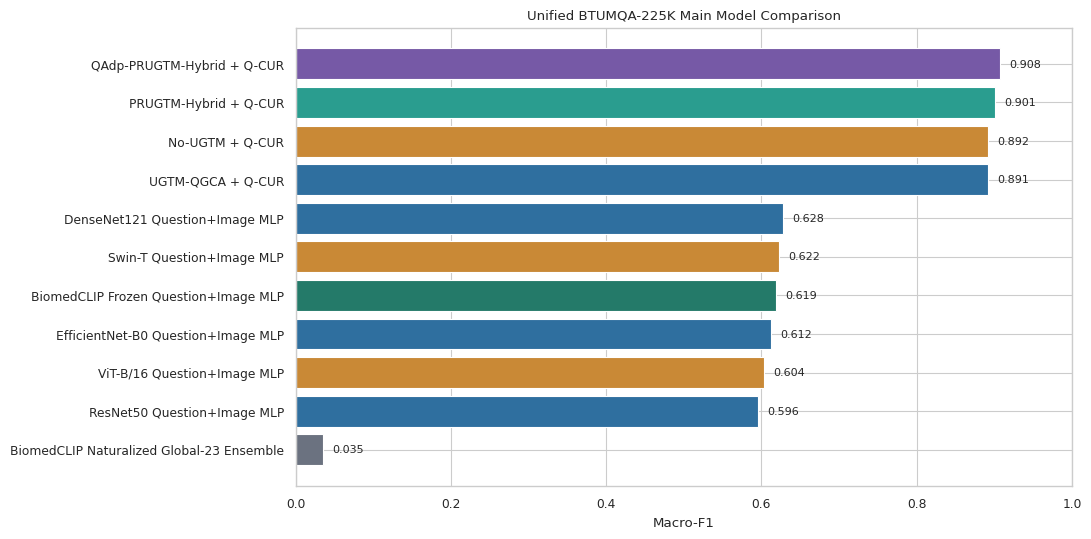

Saved /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_06a_models_unified_comparison_results_showcase/btumqa_225k_models_unified_comparison_results_showcase/figures/phase06a_unified_tiered_model_comparison.png


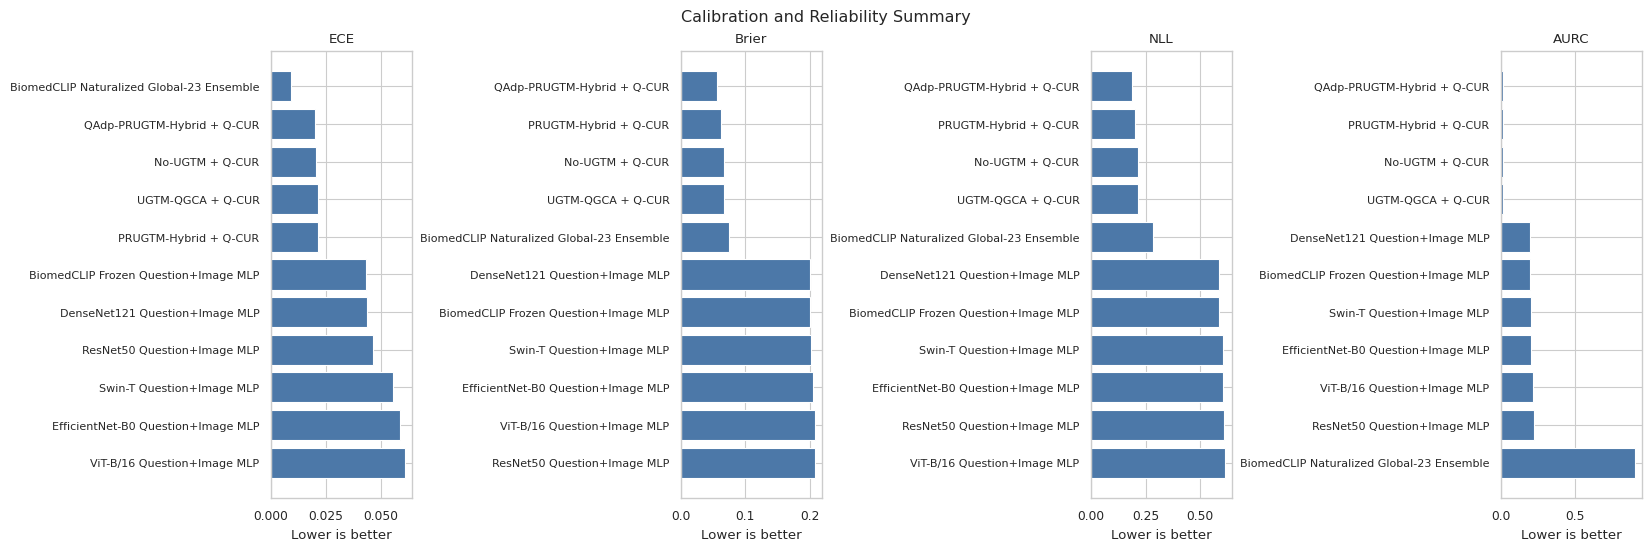

Saved /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_06a_models_unified_comparison_results_showcase/btumqa_225k_models_unified_comparison_results_showcase/figures/phase06a_unified_calibration_reliability_panel.png


In [ ]:
def metric_label(metric: str) -> str:
    return {
        "accuracy": "Accuracy",
        "macro_f1": "Macro-F1",
        "weighted_f1": "Weighted-F1",
        "ece": "ECE",
        "brier": "Brier",
        "nll": "NLL",
        "aurc": "AURC",
    }.get(metric, metric)


def save_answer_quality_figure(df: pd.DataFrame, path: Path) -> None:
    if df.empty:
        print("Skipping answer quality figure: no rows")
        return
    plot_df = df.sort_values("macro_f1", ascending=True).copy()
    fig, ax = plt.subplots(figsize=(10.8, max(4.8, 0.48 * len(plot_df))), constrained_layout=True)
    colors = [
        PHASE05B_BACKBONE_PALETTE.get(label, MODEL_FAMILY_PALETTE.get(family, "#4c78a8"))
        for label, family in zip(plot_df["model_label"], plot_df["model_family"])
    ]
    ax.barh(plot_df["model_label"], plot_df["macro_f1"], color=colors, edgecolor="white")
    ax.set_xlim(0, 1.0)
    ax.set_xlabel("Macro-F1")
    ax.set_title("Unified BTUMQA-225K Main Model Comparison")
    for y, value in enumerate(plot_df["macro_f1"].tolist()):
        if pd.notna(value):
            ax.text(min(value + 0.012, 0.98), y, f"{value:.3f}", va="center", fontsize=8)
    fig.savefig(path, dpi=260, bbox_inches="tight")
    plt.show()
    print("Saved", path)


def save_metric_panel(df: pd.DataFrame, path: Path, metrics: list[str], title: str, lower_is_better: bool = False) -> None:
    if df.empty:
        print(f"Skipping {title}: no rows")
        return
    plot_df = df.melt(
        id_vars=["model_label", "model_family", "calibration_source"],
        value_vars=[m for m in metrics if m in df.columns],
        var_name="metric",
        value_name="value",
    ).dropna(subset=["value"])
    if plot_df.empty:
        print(f"Skipping {title}: no metric values")
        return
    plot_df["metric_label"] = plot_df["metric"].map(metric_label)
    fig, axes = plt.subplots(1, len(metrics), figsize=(4.1 * len(metrics), 5.4), constrained_layout=True)
    if len(metrics) == 1:
        axes = [axes]
    for ax, metric in zip(axes, metrics):
        sub = plot_df[plot_df["metric"].eq(metric)].sort_values("value", ascending=not lower_is_better)
        ax.barh(sub["model_label"], sub["value"], color="#4c78a8", edgecolor="white")
        ax.set_title(metric_label(metric))
        ax.set_xlabel("Lower is better" if lower_is_better else "Higher is better")
        ax.tick_params(axis="y", labelsize=8)
    fig.suptitle(title)
    fig.savefig(path, dpi=260, bbox_inches="tight")
    plt.show()
    print("Saved", path)


answer_fig = FIGURES_DIR / "phase06a_unified_tiered_model_comparison.png"
reliability_fig = FIGURES_DIR / "phase06a_unified_calibration_reliability_panel.png"
dashboard_fig = FIGURES_DIR / "phase06a_models_unified_results_dashboard_summary.png"

save_answer_quality_figure(main_df, answer_fig)
save_metric_panel(main_df, reliability_fig, ["ece", "brier", "nll", "aurc"], "Calibration and Reliability Summary", lower_is_better=True)


## One-Page Results Dashboard Summary


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


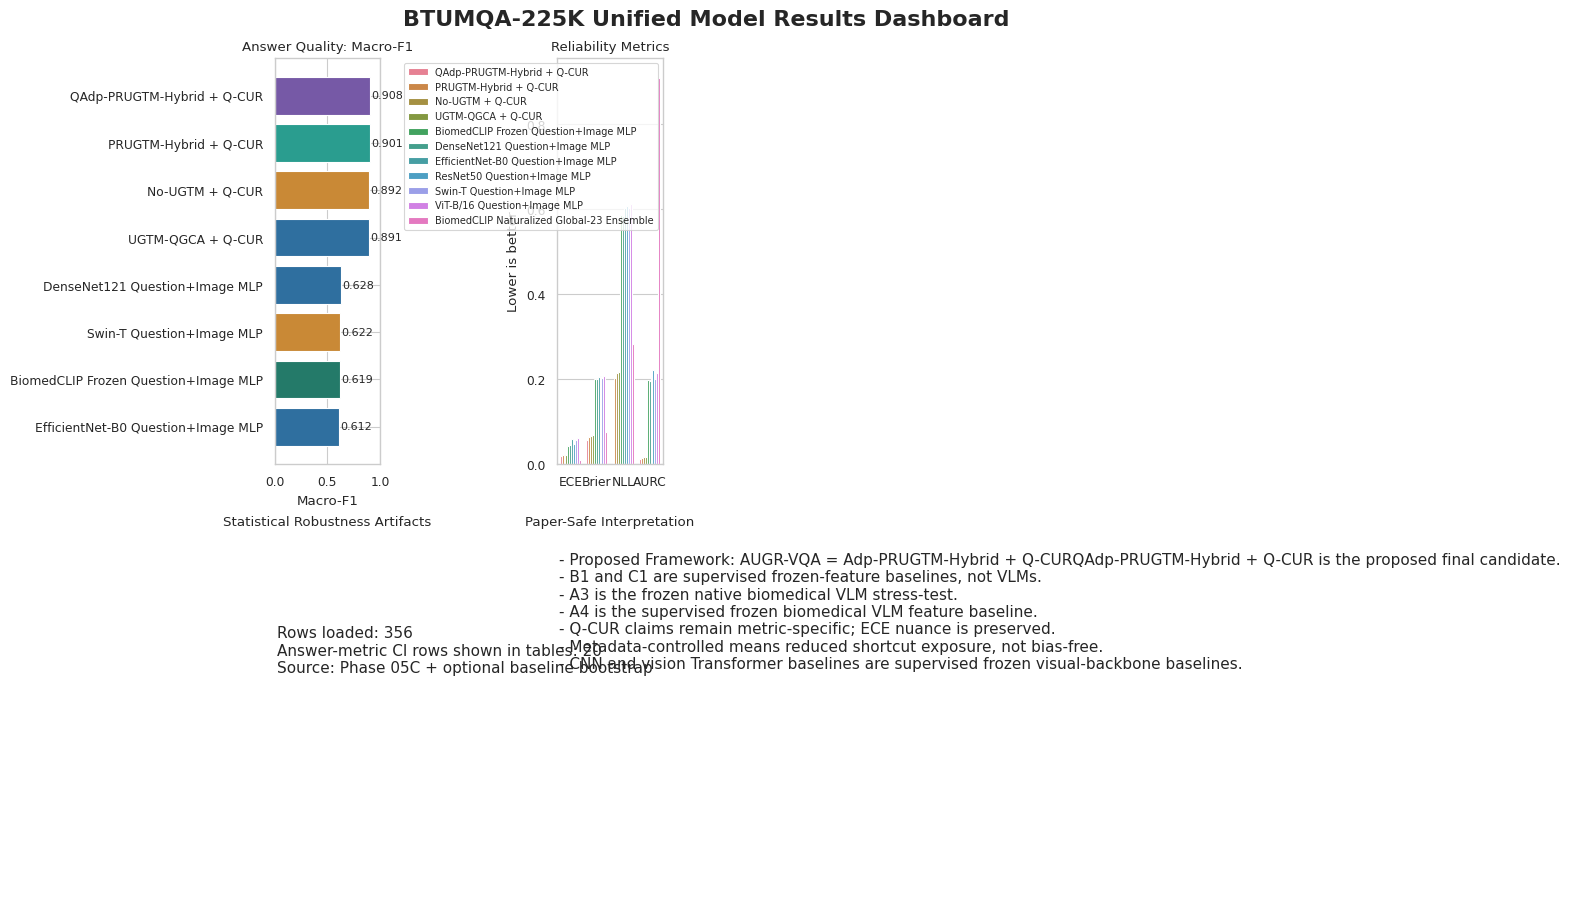

Saved /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_06a_models_unified_comparison_results_showcase/btumqa_225k_models_unified_comparison_results_showcase/figures/phase06a_models_unified_results_dashboard_summary.png


In [ ]:
def save_dashboard_summary(main_df: pd.DataFrame, calibration_df: pd.DataFrame, robustness_df: pd.DataFrame, path: Path) -> None:
    fig = plt.figure(figsize=(14, 9), constrained_layout=True)
    grid = fig.add_gridspec(2, 2, height_ratios=[1.05, 0.95])
    ax1 = fig.add_subplot(grid[0, 0])
    ax2 = fig.add_subplot(grid[0, 1])
    ax3 = fig.add_subplot(grid[1, 0])
    ax4 = fig.add_subplot(grid[1, 1])

    if not main_df.empty:
        top = main_df.sort_values("macro_f1", ascending=True).tail(8)
        top_colors = [
            PHASE05B_BACKBONE_PALETTE.get(label, MODEL_FAMILY_PALETTE.get(family, "#4c78a8"))
            for label, family in zip(top["model_label"], top["model_family"])
        ]
        ax1.barh(top["model_label"], top["macro_f1"], color=top_colors, edgecolor="white")
        ax1.set_xlim(0, 1.0)
        ax1.set_title("Answer Quality: Macro-F1")
        for y, value in enumerate(top["macro_f1"].tolist()):
            if pd.notna(value):
                ax1.text(min(value + 0.01, 0.98), y, f"{value:.3f}", va="center", fontsize=8)
    else:
        ax1.text(0.5, 0.5, "No main comparison rows", ha="center", va="center")
    ax1.set_xlabel("Macro-F1")

    rel = main_df[["model_label", "ece", "brier", "nll", "aurc"]].copy() if not main_df.empty else pd.DataFrame()
    rel = rel.dropna(subset=["ece", "brier", "nll", "aurc"], how="all")
    if not rel.empty:
        rel_plot = rel.melt(id_vars="model_label", var_name="metric", value_name="value").dropna()
        rel_plot["metric"] = rel_plot["metric"].map(metric_label)
        sns.barplot(data=rel_plot, x="metric", y="value", hue="model_label", ax=ax2)
        ax2.set_title("Reliability Metrics")
        ax2.set_xlabel("")
        ax2.set_ylabel("Lower is better")
        ax2.legend(fontsize=7, loc="upper right")
    else:
        ax2.text(0.5, 0.5, "Reliability artifacts unavailable", ha="center", va="center")

    if not robustness_df.empty and "metric" in robustness_df.columns:
        rb = robustness_df[robustness_df["metric"].astype(str).isin(["accuracy", "macro_f1", "weighted_f1"])].copy()
        rb = rb.head(20)
        ax3.axis("off")
        ax3.set_title("Statistical Robustness Artifacts")
        text = f"Rows loaded: {len(robustness_df):,}\nAnswer-metric CI rows shown in tables: {len(rb):,}\nSource: Phase 05C + optional baseline bootstrap"
        ax3.text(0.02, 0.75, text, fontsize=11, va="top")
    else:
        ax3.axis("off")
        ax3.set_title("Statistical Robustness Artifacts")
        ax3.text(0.02, 0.75, "No robustness rows loaded.", fontsize=11, va="top")

    ax4.axis("off")
    ax4.set_title("Paper-Safe Interpretation")
    notes = [
        "Proposed Framework: AUGR-VQA = Adp-PRUGTM-Hybrid + Q-CUR"
        "QAdp-PRUGTM-Hybrid + Q-CUR is the proposed final candidate.",
        "B1 and C1 are supervised frozen-feature baselines, not VLMs.",
        "A3 is the frozen native biomedical VLM stress-test.",
        "A4 is the supervised frozen biomedical VLM feature baseline.",
        "Q-CUR claims remain metric-specific; ECE nuance is preserved.",
        "Metadata-controlled means reduced shortcut exposure, not bias-free.",
        "CNN and vision Transformer baselines are supervised frozen visual-backbone baselines.",
    ]
    ax4.text(0.02, 0.95, "\n".join(f"- {note}" for note in notes), fontsize=11, va="top")

    fig.suptitle("BTUMQA-225K Unified Model Results Dashboard", fontsize=16, fontweight="bold")
    fig.savefig(path, dpi=260, bbox_inches="tight")
    plt.show()
    print("Saved", path)


save_dashboard_summary(main_df, calibration_df, robustness_df, dashboard_fig)


## All-Model Visual Panels and Table Figures

This section creates dedicated visuals for all available models across evaluation, ablation/control comparison, calibration/reliability, and statistical robustness. It also renders the main result tables as publication-style figure images for quick paper inspection.


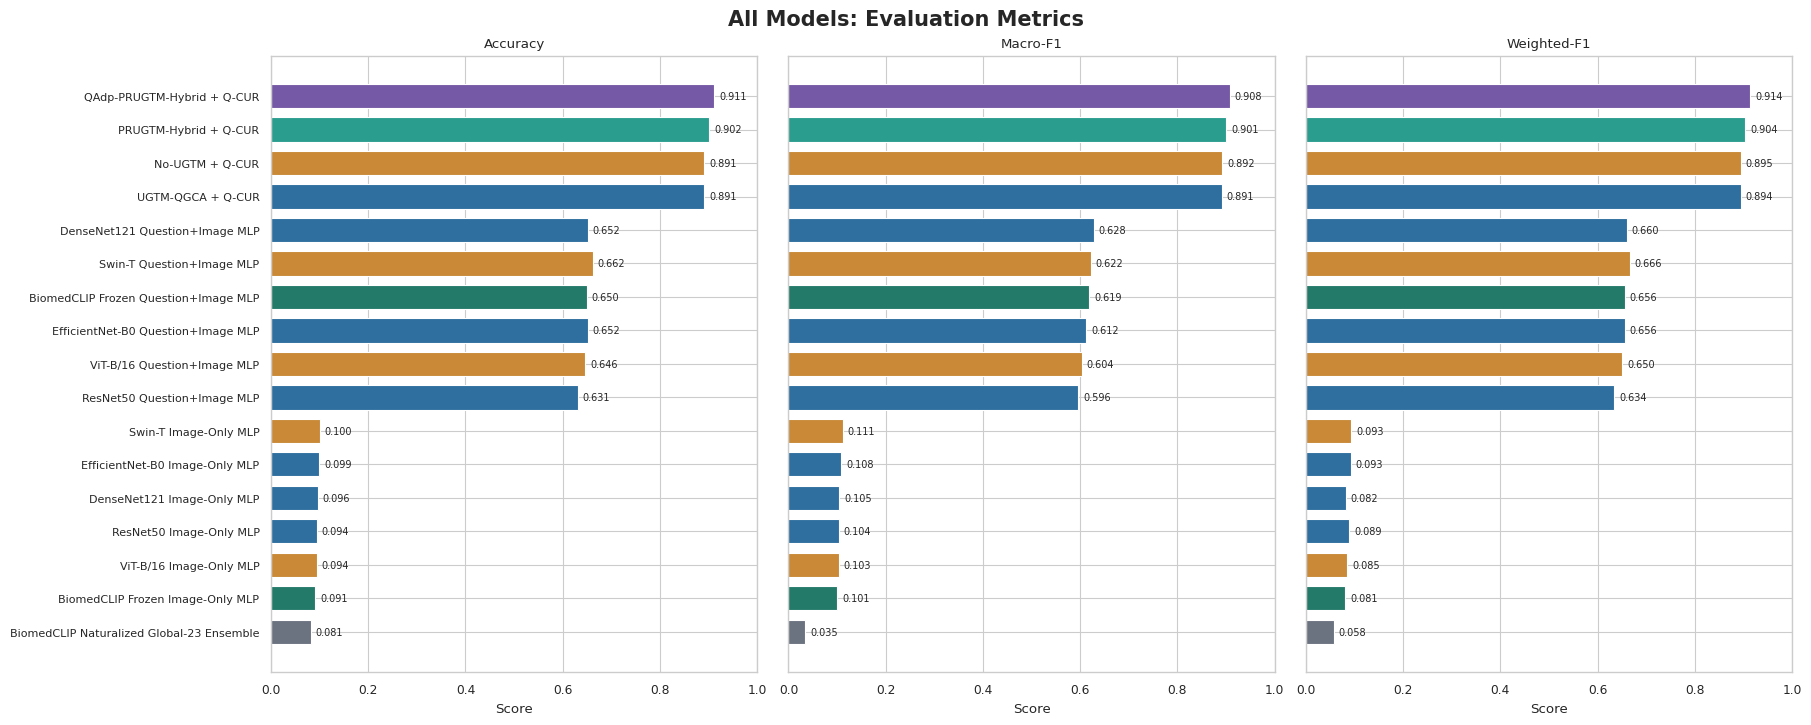

Saved /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_06a_models_unified_comparison_results_showcase/btumqa_225k_models_unified_comparison_results_showcase/figures/phase06a_all_models_evaluation_metrics.png


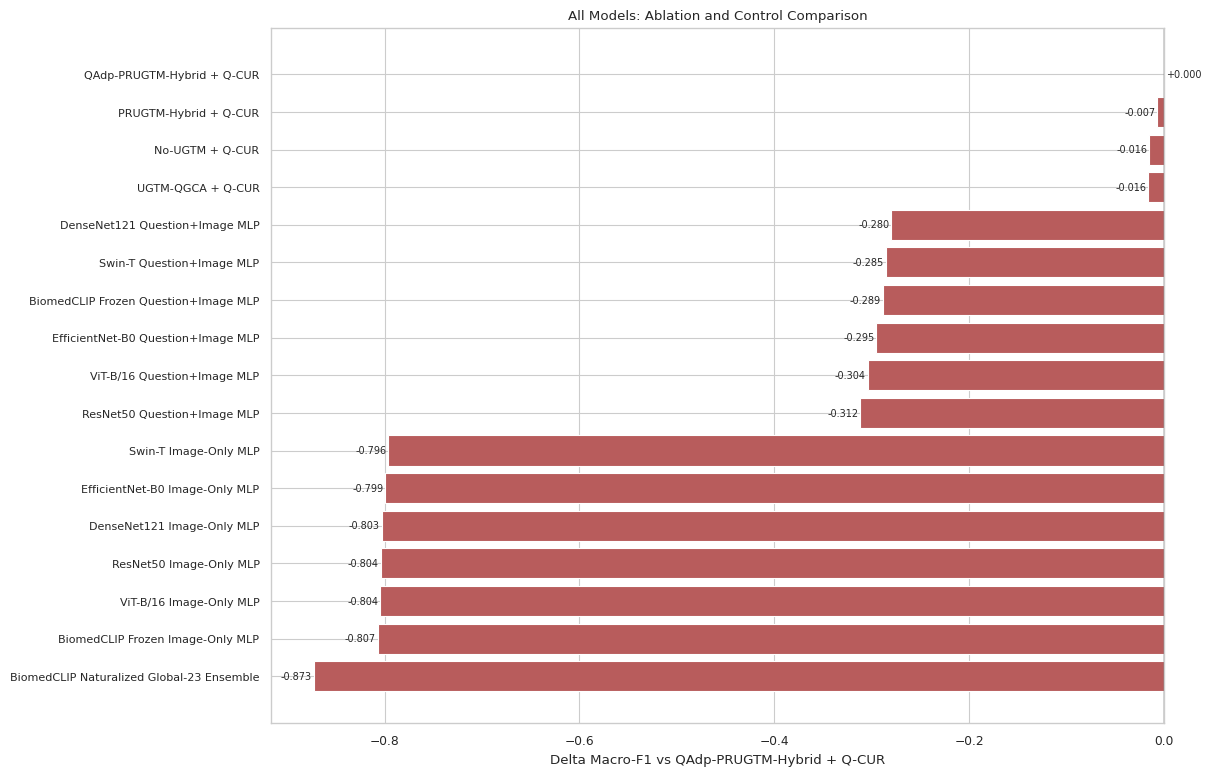

Saved /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_06a_models_unified_comparison_results_showcase/btumqa_225k_models_unified_comparison_results_showcase/figures/phase06a_all_models_ablation_comparison.png


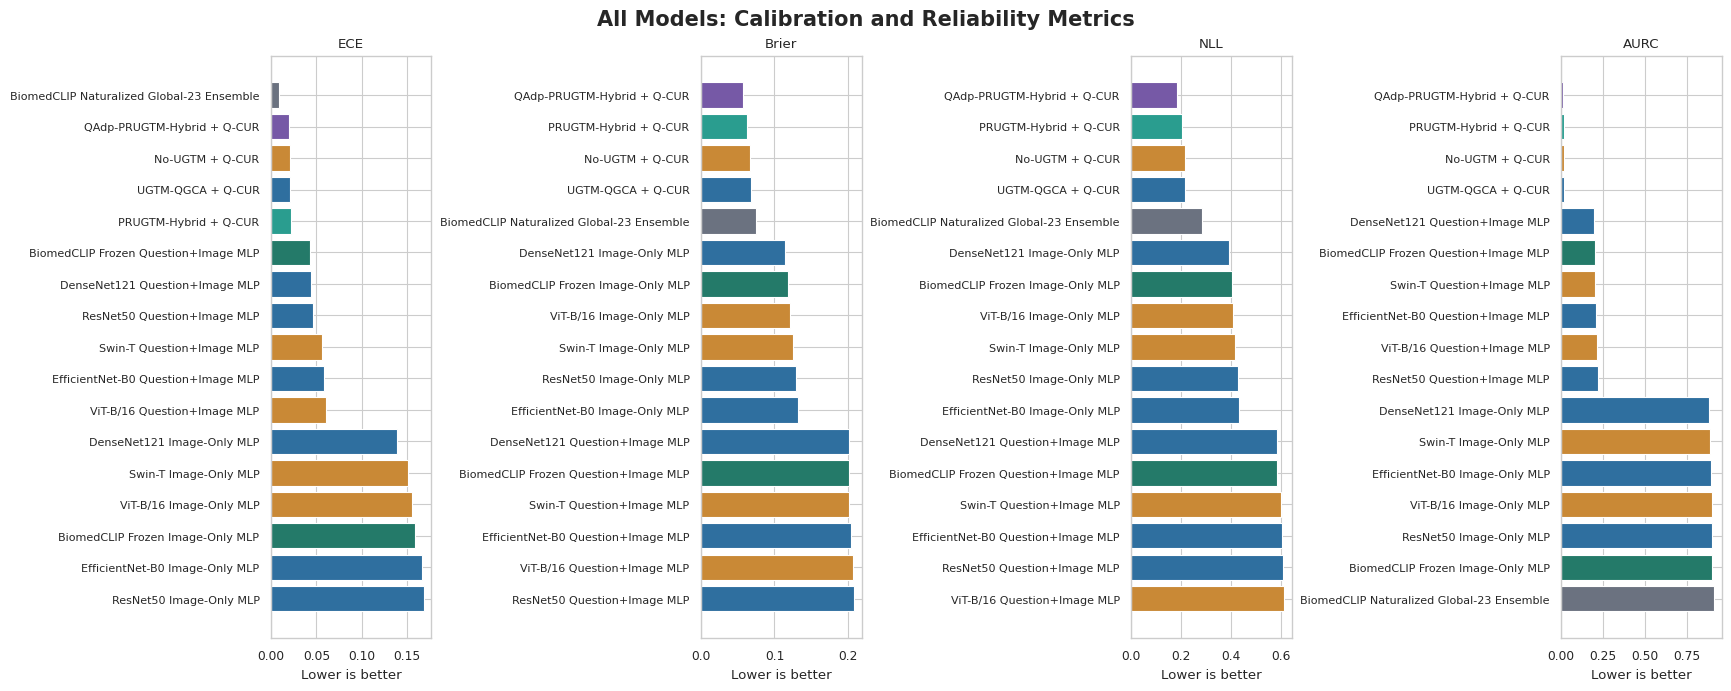

Saved /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_06a_models_unified_comparison_results_showcase/btumqa_225k_models_unified_comparison_results_showcase/figures/phase06a_all_models_calibration_reliability.png


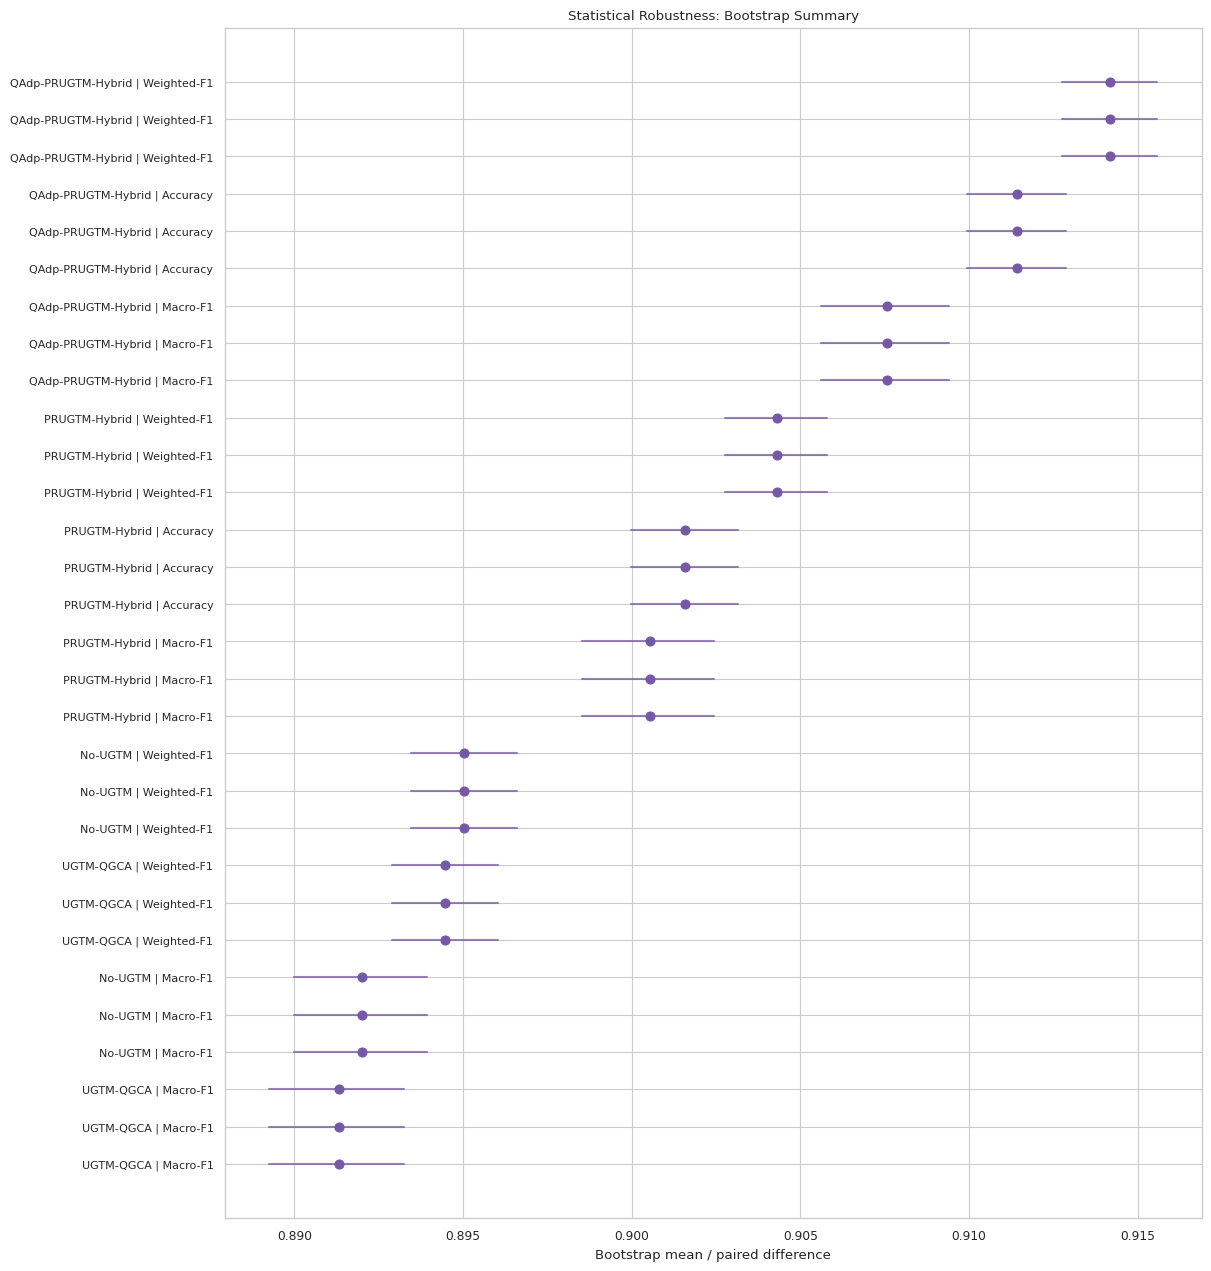

Saved /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_06a_models_unified_comparison_results_showcase/btumqa_225k_models_unified_comparison_results_showcase/figures/phase06a_all_models_statistical_robustness.png


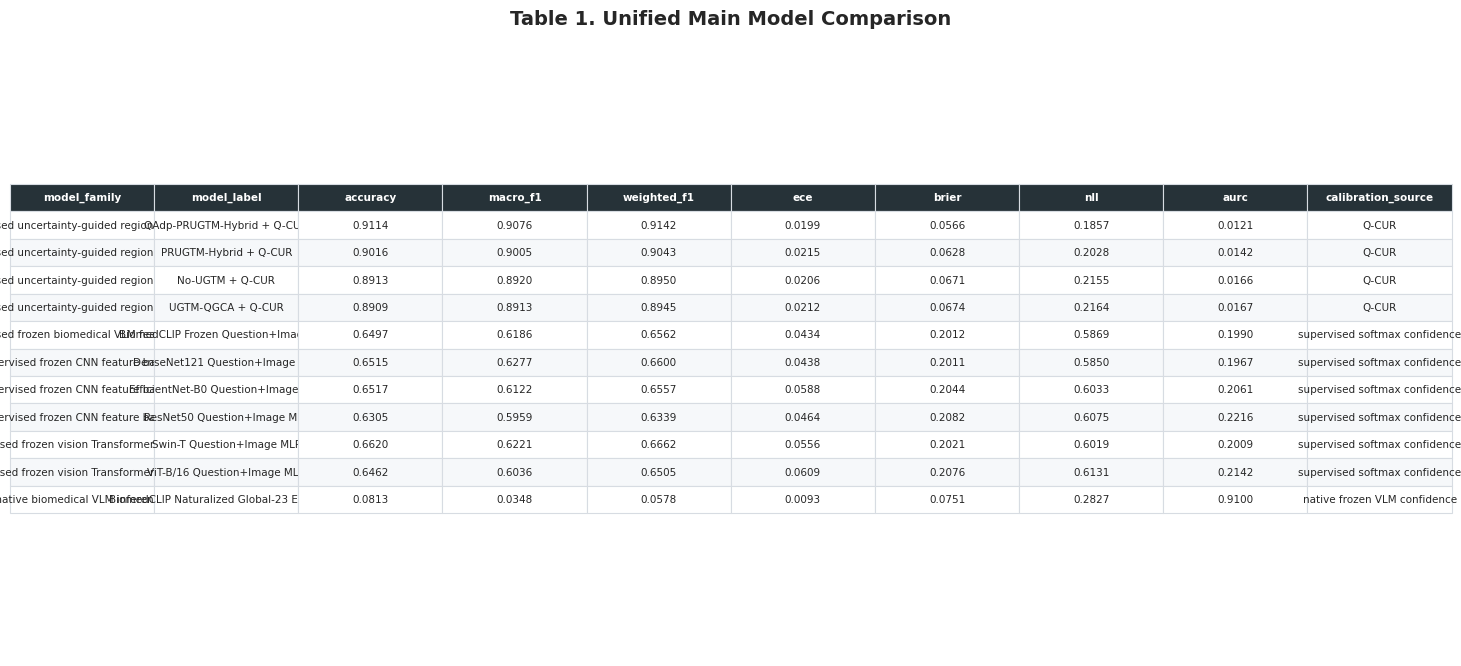

Saved /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_06a_models_unified_comparison_results_showcase/btumqa_225k_models_unified_comparison_results_showcase/figures/phase06a_table_main_model_comparison.png


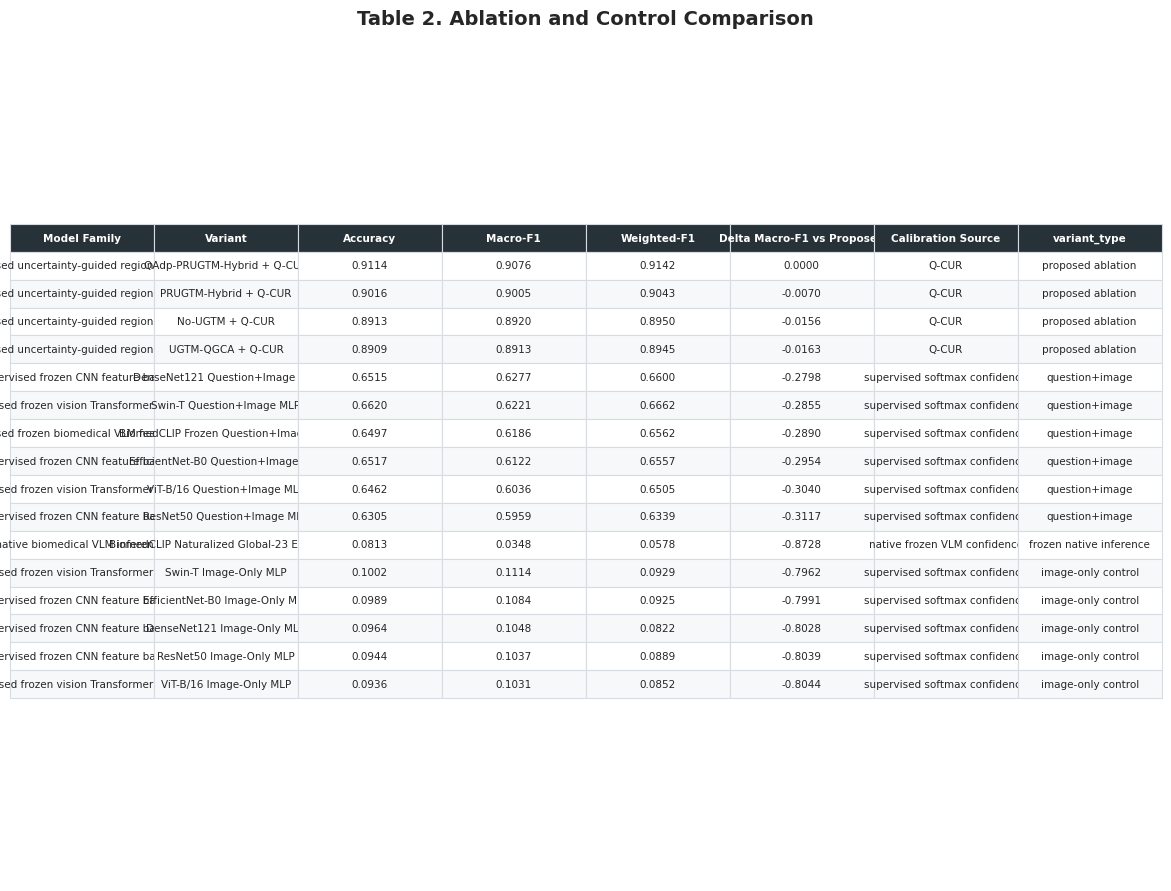

Saved /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_06a_models_unified_comparison_results_showcase/btumqa_225k_models_unified_comparison_results_showcase/figures/phase06a_table_ablation_comparison.png


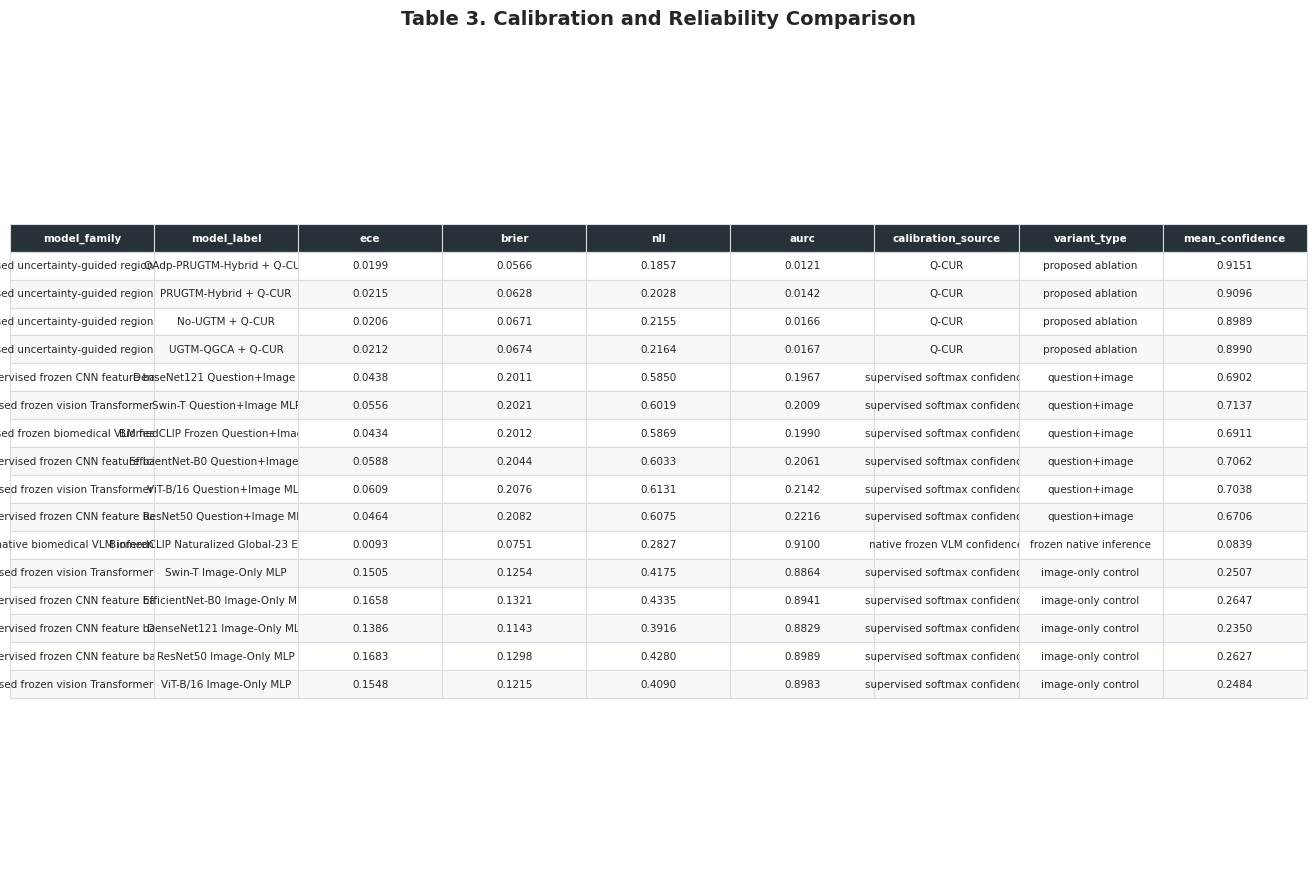

Saved /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_06a_models_unified_comparison_results_showcase/btumqa_225k_models_unified_comparison_results_showcase/figures/phase06a_table_calibration_reliability.png


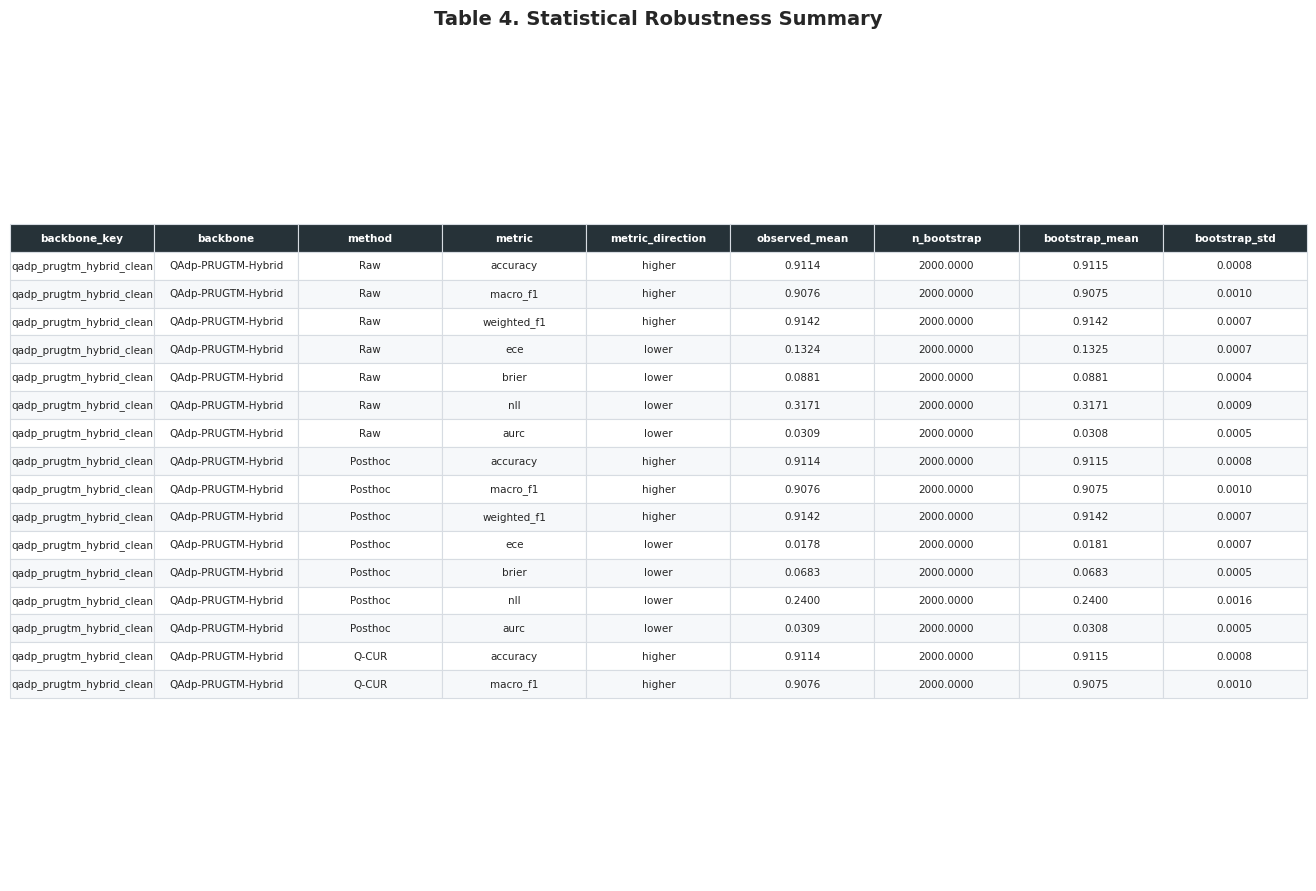

Saved /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_06a_models_unified_comparison_results_showcase/btumqa_225k_models_unified_comparison_results_showcase/figures/phase06a_table_statistical_robustness.png


In [ ]:
def _safe_metric_frame(df: pd.DataFrame, metrics: list[str]) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()
    keep = [m for m in metrics if m in df.columns]
    if not keep:
        return pd.DataFrame()
    id_cols = [col for col in ["model_family", "model_label", "variant_type", "calibration_source"] if col in df.columns]
    out = df[id_cols + keep].copy()
    for col in keep:
        out[col] = pd.to_numeric(out[col], errors="coerce")
    return out


def _family_color(label: str, family: str) -> str:
    return PHASE05B_BACKBONE_PALETTE.get(str(label), MODEL_FAMILY_PALETTE.get(str(family), "#4c78a8"))


def save_all_models_evaluation_visual(df: pd.DataFrame, path: Path) -> None:
    metrics = ["accuracy", "macro_f1", "weighted_f1"]
    metric_df = _safe_metric_frame(df, metrics)
    if metric_df.empty:
        print("Skipping all-model evaluation visual: no metric rows")
        return
    plot_df = metric_df.sort_values(["macro_f1", "accuracy"], ascending=True).copy()
    fig, axes = plt.subplots(1, 3, figsize=(18, max(6, 0.42 * len(plot_df))), sharey=True, constrained_layout=True)
    colors = [_family_color(row["model_label"], row["model_family"]) for _, row in plot_df.iterrows()]
    for ax, metric in zip(axes, metrics):
        ax.barh(plot_df["model_label"], plot_df[metric], color=colors, edgecolor="white", height=0.72)
        ax.set_xlim(0, 1.0)
        ax.set_title(metric_label(metric))
        ax.set_xlabel("Score")
        ax.tick_params(axis="y", labelsize=8)
        for y, value in enumerate(plot_df[metric].tolist()):
            if pd.notna(value):
                ax.text(min(value + 0.01, 0.98), y, f"{value:.3f}", va="center", fontsize=7)
    fig.suptitle("All Models: Evaluation Metrics", fontsize=15, fontweight="bold")
    fig.savefig(path, dpi=260, bbox_inches="tight")
    plt.show()
    print("Saved", path)


def save_all_models_ablation_visual(ablation_table: pd.DataFrame, path: Path) -> None:
    if ablation_table.empty or "Delta Macro-F1 vs Proposed" not in ablation_table.columns:
        print("Skipping all-model ablation visual: ablation delta not available")
        return
    plot_df = ablation_table.copy()
    plot_df["Delta Macro-F1 vs Proposed"] = pd.to_numeric(plot_df["Delta Macro-F1 vs Proposed"], errors="coerce")
    plot_df = plot_df.dropna(subset=["Delta Macro-F1 vs Proposed"]).sort_values("Delta Macro-F1 vs Proposed", ascending=True)
    if plot_df.empty:
        print("Skipping all-model ablation visual: no numeric deltas")
        return
    colors = np.where(plot_df["Delta Macro-F1 vs Proposed"] >= 0, "#247a69", "#b85c5c")
    fig, ax = plt.subplots(figsize=(12, max(6, 0.45 * len(plot_df))), constrained_layout=True)
    ax.barh(plot_df["Variant"], plot_df["Delta Macro-F1 vs Proposed"], color=colors, edgecolor="white")
    ax.axvline(0, color="#333333", linewidth=1)
    ax.set_xlabel("Delta Macro-F1 vs QAdp-PRUGTM-Hybrid + Q-CUR")
    ax.set_title("All Models: Ablation and Control Comparison")
    ax.tick_params(axis="y", labelsize=8)
    for y, value in enumerate(plot_df["Delta Macro-F1 vs Proposed"].tolist()):
        ax.text(value + (0.002 if value >= 0 else -0.002), y, f"{value:+.3f}", va="center", ha="left" if value >= 0 else "right", fontsize=7)
    fig.savefig(path, dpi=260, bbox_inches="tight")
    plt.show()
    print("Saved", path)


def save_all_models_calibration_visual(df: pd.DataFrame, path: Path) -> None:
    metrics = ["ece", "brier", "nll", "aurc"]
    metric_df = _safe_metric_frame(df, metrics)
    if metric_df.empty:
        print("Skipping all-model calibration visual: no reliability rows")
        return
    plot_df = metric_df.melt(
        id_vars=[col for col in ["model_family", "model_label", "variant_type", "calibration_source"] if col in metric_df.columns],
        value_vars=[m for m in metrics if m in metric_df.columns],
        var_name="metric",
        value_name="value",
    ).dropna(subset=["value"])
    if plot_df.empty:
        print("Skipping all-model calibration visual: no numeric reliability values")
        return
    plot_df["metric_label"] = plot_df["metric"].map(metric_label)
    fig, axes = plt.subplots(1, len(metrics), figsize=(4.3 * len(metrics), max(6, 0.4 * df["model_label"].nunique())), constrained_layout=True)
    for ax, metric in zip(axes, metrics):
        sub = plot_df[plot_df["metric"].eq(metric)].sort_values("value", ascending=False)
        colors = [_family_color(row["model_label"], row["model_family"]) for _, row in sub.iterrows()]
        ax.barh(sub["model_label"], sub["value"], color=colors, edgecolor="white")
        ax.set_title(metric_label(metric))
        ax.set_xlabel("Lower is better")
        ax.tick_params(axis="y", labelsize=8)
    fig.suptitle("All Models: Calibration and Reliability Metrics", fontsize=15, fontweight="bold")
    fig.savefig(path, dpi=260, bbox_inches="tight")
    plt.show()
    print("Saved", path)


def save_statistical_robustness_visual(df: pd.DataFrame, path: Path) -> None:
    if df.empty or "metric" not in df.columns:
        print("Skipping statistical robustness visual: no robustness rows")
        return
    plot_df = df[df["metric"].astype(str).isin(["accuracy", "macro_f1", "weighted_f1"])].copy()
    center_col = next((col for col in ["observed_mean", "bootstrap_mean", "mean", "bootstrap_mean_difference", "observed_difference"] if col in plot_df.columns), None)
    low_col = next((col for col in ["ci_lower", "ci_low", "bootstrap_ci_low", "ci95_low"] if col in plot_df.columns), None)
    high_col = next((col for col in ["ci_upper", "ci_high", "bootstrap_ci_high", "ci95_high"] if col in plot_df.columns), None)
    label_col = next((col for col in ["backbone", "model_label", "model_key", "comparison_id", "comparison"] if col in plot_df.columns), None)
    if center_col is None or label_col is None:
        print("Skipping statistical robustness visual: required center/label columns not found")
        return
    plot_df[center_col] = pd.to_numeric(plot_df[center_col], errors="coerce")
    if low_col:
        plot_df[low_col] = pd.to_numeric(plot_df[low_col], errors="coerce")
    if high_col:
        plot_df[high_col] = pd.to_numeric(plot_df[high_col], errors="coerce")
    plot_df = plot_df.dropna(subset=[center_col]).copy()
    if plot_df.empty:
        print("Skipping statistical robustness visual: no numeric robustness values")
        return
    plot_df["display_label"] = plot_df[label_col].astype(str) + " | " + plot_df["metric"].map(metric_label)
    plot_df = plot_df.sort_values(center_col, ascending=True).tail(30)
    fig, ax = plt.subplots(figsize=(12, max(6, 0.42 * len(plot_df))), constrained_layout=True)
    y = np.arange(len(plot_df))
    ax.scatter(plot_df[center_col], y, color="#7659a6", s=42, zorder=3)
    if low_col and high_col:
        for idx, row in enumerate(plot_df.itertuples(index=False)):
            low = getattr(row, low_col)
            high = getattr(row, high_col)
            center = getattr(row, center_col)
            if pd.notna(low) and pd.notna(high):
                ax.plot([low, high], [idx, idx], color="#7659a6", linewidth=1.5, alpha=0.75)
                ax.plot([center], [idx], marker="o", color="#7659a6")
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["display_label"], fontsize=8)
    ax.set_xlabel("Bootstrap mean / paired difference")
    ax.set_title("Statistical Robustness: Bootstrap Summary")
    fig.savefig(path, dpi=260, bbox_inches="tight")
    plt.show()
    print("Saved", path)


def save_table_visual(df: pd.DataFrame, path: Path, title: str, max_rows: int = 14, max_cols: int = 9) -> None:
    if df.empty:
        print(f"Skipping table visual for {title}: table is empty")
        return
    show_df = df.copy().head(max_rows)
    preferred_cols = [
        "model_family", "model_label", "Model Family", "Variant", "accuracy", "Accuracy",
        "macro_f1", "Macro-F1", "weighted_f1", "Weighted-F1", "ece", "brier", "nll", "aurc",
        "Delta Macro-F1 vs Proposed", "Calibration Source", "calibration_source",
    ]
    cols = [col for col in preferred_cols if col in show_df.columns]
    if len(cols) < min(max_cols, len(show_df.columns)):
        cols.extend([col for col in show_df.columns if col not in cols])
    show_df = show_df[cols[:max_cols]].copy()
    for col in show_df.columns:
        if pd.api.types.is_numeric_dtype(show_df[col]):
            show_df[col] = show_df[col].map(lambda x: "" if pd.isna(x) else f"{x:.4f}")
        else:
            show_df[col] = show_df[col].astype(str).str.slice(0, 46)
    fig_height = max(3.2, 0.45 * len(show_df) + 1.6)
    fig_width = max(10.5, 1.45 * len(show_df.columns))
    fig, ax = plt.subplots(figsize=(fig_width, fig_height), constrained_layout=True)
    ax.axis("off")
    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
    table = ax.table(cellText=show_df.values, colLabels=show_df.columns, loc="center", cellLoc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(7.5)
    table.scale(1.0, 1.35)
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("#d7dce2")
        if row == 0:
            cell.set_facecolor("#263238")
            cell.set_text_props(color="white", weight="bold")
        elif row % 2 == 0:
            cell.set_facecolor("#f6f8fa")
        else:
            cell.set_facecolor("white")
    fig.savefig(path, dpi=260, bbox_inches="tight")
    plt.show()
    print("Saved", path)


all_models_eval_fig = FIGURES_DIR / "phase06a_all_models_evaluation_metrics.png"
all_models_ablation_fig = FIGURES_DIR / "phase06a_all_models_ablation_comparison.png"
all_models_calibration_fig = FIGURES_DIR / "phase06a_all_models_calibration_reliability.png"
all_models_robustness_fig = FIGURES_DIR / "phase06a_all_models_statistical_robustness.png"
main_table_fig = FIGURES_DIR / "phase06a_table_main_model_comparison.png"
ablation_table_fig = FIGURES_DIR / "phase06a_table_ablation_comparison.png"
calibration_table_fig = FIGURES_DIR / "phase06a_table_calibration_reliability.png"
robustness_table_fig = FIGURES_DIR / "phase06a_table_statistical_robustness.png"

save_all_models_evaluation_visual(unified_df, all_models_eval_fig)
save_all_models_ablation_visual(ablation_df, all_models_ablation_fig)
save_all_models_calibration_visual(unified_df, all_models_calibration_fig)
save_statistical_robustness_visual(robustness_df, all_models_robustness_fig)

save_table_visual(main_df, main_table_fig, "Table 1. Unified Main Model Comparison", max_rows=12, max_cols=10)
save_table_visual(ablation_df, ablation_table_fig, "Table 2. Ablation and Control Comparison", max_rows=16, max_cols=8)
save_table_visual(calibration_df, calibration_table_fig, "Table 3. Calibration and Reliability Comparison", max_rows=16, max_cols=9)
save_table_visual(robustness_df, robustness_table_fig, "Table 4. Statistical Robustness Summary", max_rows=16, max_cols=9)

ADDITIONAL_PHASE06A_FIGURES = {
    "all_models_evaluation_metrics": str(all_models_eval_fig),
    "all_models_ablation_comparison": str(all_models_ablation_fig),
    "all_models_calibration_reliability": str(all_models_calibration_fig),
    "all_models_statistical_robustness": str(all_models_robustness_fig),
    "table_main_model_comparison": str(main_table_fig),
    "table_ablation_comparison": str(ablation_table_fig),
    "table_calibration_reliability": str(calibration_table_fig),
    "table_statistical_robustness": str(robustness_table_fig),
}


## Final Report and Done Marker


In [ ]:
report = {
    "finished_at": now_string(),
    "notebook": "BrainTumorVQA_Phase_06A_(BTUMQA_225K_Models_Unified_Results_Comparison)",
    "output_dir": str(PHASE06A_DIR),
    "artifact_availability": availability_df.to_dict(orient="records"),
    "row_counts": {
        "main_paper_rows": int(len(main_df)),
        "ablation_rows": int(len(ablation_df)),
        "calibration_rows": int(len(calibration_df)),
        "supplementary_rows": int(len(unified_df)),
        "robustness_rows": int(len(robustness_df)),
    },
    "tables": {key: str(path) for key, path in OUTPUT_PATHS.items() if key not in {"report", "done"}},
    "figures": {
        "tiered_model_comparison": str(answer_fig),
        "calibration_reliability_panel": str(reliability_fig),
        "dashboard_summary": str(dashboard_fig),
    },
    "paper_safe_claims": [
        "Proposed Framework: AUGR-VQA = Adp-PRUGTM-Hybrid + Q-CUR"
        "CNN and vision Transformer baselines are supervised frozen visual-backbone baselines.",
        "A3 is the frozen native biomedical VLM inference baseline.",
        "A4 is the supervised frozen biomedical VLM feature baseline.",
        "Q-CUR is not claimed to be best on every calibration metric.",
        "Metadata-controlled training is not claimed to be bias-free.",
        "A3/A4/B1/C1 are not claimed to use uncertainty-aware regional reasoning.",
    ],
}

write_json(OUTPUT_PATHS["report"], report)
write_json(OUTPUT_PATHS["done"], report)
print("Phase 06A dashboard synthesis complete.")
report


Phase 06A dashboard synthesis complete.


{'finished_at': '2026-06-09 12:23:25',
 'notebook': 'BrainTumorVQA_Phase_06A_(BTUMQA_225K_Models_Unified_Results_Comparison)',
 'output_dir': '/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_06a_models_unified_comparison_results_showcase/btumqa_225k_models_unified_comparison_results_showcase',
 'artifact_availability': [{'artifact': 'phase5b_answer',
   'path': '/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5b_final_evaluation_ablation_calibration/btumqa_225k_clean_metadata_four_seeds_final_comparison/tables/phase5b_clean_metadata_four_seeds_answer_backbone_table.csv',
   'exists': True,
   'status': 'ready',
   'notebook_action': 'load artifact'},
  {'artifact': 'phase5b_ablation',
   'path': '/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5b_final_evaluation_ablation_calibration/btumqa_225k_clean_metadat